# Import data

In [1]:
import pandas as pd
import numpy as np
from statsbombpy import sb
from mplsoccer import Pitch, VerticalPitch
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, fixed, IntSlider
%matplotlib inline

from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
from collections import defaultdict
from pathlib import Path
import os

pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)        # To avoid linebreaks
pd.set_option('display.max_rows', None)

In [2]:
sb.competitions().head()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,NaN,NaN,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,NaN,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882


In [3]:
sb.competitions()[sb.competitions()['match_available_360'].notna()]

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
29,43,106,International,FIFA World Cup,male,False,True,2022,2024-12-16T10:15:11.055845,2024-12-16T10:21:13.710934,2024-12-16T10:21:13.710934,2024-12-16T10:15:11.055845
38,11,90,Spain,La Liga,male,False,False,2020/2021,2025-01-29T17:39:28.924386,2025-01-29T18:09:18.620699,2025-01-29T18:09:18.620699,2025-01-29T17:39:28.924386
58,7,235,France,Ligue 1,male,False,False,2022/2023,2024-12-19T13:56:45.683863,2025-06-30T02:31:32.046070,2025-06-30T02:31:32.046070,2024-12-19T13:56:45.683863
59,7,108,France,Ligue 1,male,False,False,2021/2022,2025-06-15T12:56:15.594872,2025-06-15T13:02:45.341609,2025-06-15T13:02:45.341609,2025-06-15T12:56:15.594872
61,44,107,United States of America,Major League Soccer,male,False,False,2023,2025-06-15T12:48:12.599307,2025-07-01T11:17:29.514495,2025-07-01T11:17:29.514495,2025-06-15T12:48:12.599307
68,55,282,Europe,UEFA Euro,male,False,True,2024,2024-09-28T16:51:20.698794,2025-03-24T14:12:30.785094,2025-03-24T14:12:30.785094,2024-09-28T16:51:20.698794
69,55,43,Europe,UEFA Euro,male,False,True,2020,2024-07-31T12:29:15.702309,2024-07-31T12:30:57.587087,2024-07-31T12:30:57.587087,2024-07-31T12:29:15.702309
71,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2025-07-28T14:19:20.467348,2025-07-29T16:03:07.355174,2025-07-29T16:03:07.355174,2025-07-28T14:19:20.467348
72,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2024-02-13T13:27:17.178263,2024-02-13T13:30:52.820588,2024-02-13T13:30:52.820588,2024-02-13T13:27:17.178263


In [4]:
dfRaw=sb.matches(competition_id=55, season_id=282)
dfRaw

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_id,competition_country_name,competition_name,competition,season_id,season,home_team_id,home_team,home_team_gender,home_team_group,home_team_country_id,home_team_country_name,away_team_id,away_team,away_team_gender,away_team_group,away_team_country_id,away_team_country_name,competition_stage_id,competition_stage,stadium_id,stadium,stadium_country_id,stadium_country_name,referee_id,referee,referee_country_id,referee_country_name,home_managers,away_managers,home_manager_id,home_manager_name,home_manager_nickname,home_manager_dob,home_manager_country_id,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
0,3942819,2024-07-10,22:00:00.000,1,2,available,available,2024-07-15T07:54:23.583297,2024-07-15T07:57:36.684453,6,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,941,Netherlands,male,None,160,Netherlands,768,England,male,None,68,England,15,Semi-finals,373,Signal-Iduna-Park,85,Germany,241,Felix Zwayer,85,Germany,Ronald Koeman,Gareth Southgate,676,Ronald Koeman,NaN,1963-03-21,160,Netherlands,277,Gareth Southgate,NaN,1970-09-03,68,England,1.1.0,2,2
1,3943043,2024-07-14,22:00:00.000,2,1,available,available,2024-07-15T15:48:50.315500,2024-07-15T15:52:24.778809,7,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,768,England,male,None,68,England,26,Final,367,Olympiastadion Berlin,85,Germany,79,François Letexier,78,France,Luis de la Fuente Castillo,Gareth Southgate,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,277,Gareth Southgate,NaN,1970-09-03,68,England,1.1.0,2,2
2,3942752,2024-07-09,22:00:00.000,2,1,available,available,2024-07-10T08:51:07.032303,2024-07-10T13:01:26.597509,6,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,771,France,male,None,78,France,15,Semi-finals,4867,Allianz Arena,85,Germany,943,Slavko Vinčić,208,Slovenia,Luis de la Fuente Castillo,Didier Deschamps,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,545,Didier Deschamps,NaN,1968-10-15,78,France,1.1.0,2,2
3,3942382,2024-07-06,22:00:00.000,2,1,available,available,2024-07-10T06:50:04.068615,2024-07-10T06:56:35.146850,5,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,941,Netherlands,male,None,160,Netherlands,909,Turkey,male,None,233,Turkey,11,Quarter-finals,367,Olympiastadion Berlin,85,Germany,76,Clément Turpin,78,France,Ronald Koeman,Vincenzo Montella,676,Ronald Koeman,NaN,1963-03-21,160,Netherlands,232,Vincenzo Montella,NaN,1974-06-18,112,Italy,1.1.0,2,2
4,3942349,2024-07-05,22:00:00.000,0,0,available,available,2024-07-12T01:57:15.210934,2024-07-12T02:00:16.871522,5,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,780,Portugal,male,None,183,Portugal,771,France,male,None,78,France,11,Quarter-finals,379,Volksparkstadion,85,Germany,1,Michael Oliver,68,England,Roberto Martínez Montoliú,Didier Deschamps,263,Roberto Martínez Montoliú,Roberto Martínez,1973-07-13,214,Spain,545,Didier Deschamps,NaN,1968-10-15,78,France,1.1.0,2,2
5,3930180,2024-06-25,19:00:00.000,2,3,available,available,2024-07-11T13:24:55.422159,2024-07-11T13:25:37.289456,3,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,941,Netherlands,male,None,160,Netherlands,915,Austria,male,None,15,Austria,10,Group Stage,367,Olympiastadion Berlin,85,Germany,941,Ivan Kružliak,207,Slovakia,Ronald Koeman,Ralf Rangnick,676,Ronald Koeman,NaN,1963-03-21,160,Netherlands,380,Ralf Rangnick,NaN,1958-06-29,85,Germany,1.1.0,2,2
6,3930171,2024-06-20,19:00:00.000,1,1,available,available,2024-07-12T05:16:00.445930,2024-07-12T05:19:44.572914,2,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,776,Denmark,male,None,61,Denmark,768,England,male,None,68,England,10,Group Stage,116458,Deutsche Bank Park,85,Germany,2445,Artur Manuel Ribeiro Soares Dias,183,Portuga

In [5]:
dfRaw.columns

Index(['match_id', 'match_date', 'kick_off', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'match_week', 'competition_id', 'competition_country_name', 'competition_name', 'competition', 'season_id', 'season', 'home_team_id', 'home_team', 'home_team_gender', 'home_team_group', 'home_team_country_id', 'home_team_country_name', 'away_team_id', 'away_team', 'away_team_gender', 'away_team_group', 'away_team_country_id', 'away_team_country_name', 'competition_stage_id', 'competition_stage', 'stadium_id', 'stadium', 'stadium_country_id', 'stadium_country_name', 'referee_id', 'referee', 'referee_country_id', 'referee_country_name', 'home_managers', 'away_managers', 'home_manager_id', 'home_manager_name', 'home_manager_nickname', 'home_manager_dob', 'home_manager_country_id', 'home_manager_country_name', 'away_manager_id', 'away_manager_name', 'away_manager_nickname', 'away_manager_dob', 'away_manager_country_id',
       'away_manager_countr

In [6]:
country = 'Spain'
dfSpainAll = dfRaw[(dfRaw['home_team_country_name'] == country) | (dfRaw['away_team_country_name'] == country)]

dfSpainAll

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_id,competition_country_name,competition_name,competition,season_id,season,home_team_id,home_team,home_team_gender,home_team_group,home_team_country_id,home_team_country_name,away_team_id,away_team,away_team_gender,away_team_group,away_team_country_id,away_team_country_name,competition_stage_id,competition_stage,stadium_id,stadium,stadium_country_id,stadium_country_name,referee_id,referee,referee_country_id,referee_country_name,home_managers,away_managers,home_manager_id,home_manager_name,home_manager_nickname,home_manager_dob,home_manager_country_id,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
1,3943043,2024-07-14,22:00:00.000,2,1,available,available,2024-07-15T15:48:50.315500,2024-07-15T15:52:24.778809,7,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,768,England,male,None,68,England,26,Final,367,Olympiastadion Berlin,85,Germany,79,François Letexier,78,France,Luis de la Fuente Castillo,Gareth Southgate,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,277,Gareth Southgate,NaN,1970-09-03,68,England,1.1.0,2,2
2,3942752,2024-07-09,22:00:00.000,2,1,available,available,2024-07-10T08:51:07.032303,2024-07-10T13:01:26.597509,6,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,771,France,male,None,78,France,15,Semi-finals,4867,Allianz Arena,85,Germany,943,Slavko Vinčić,208,Slovenia,Luis de la Fuente Castillo,Didier Deschamps,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,545,Didier Deschamps,NaN,1968-10-15,78,France,1.1.0,2,2
8,3942226,2024-07-05,19:00:00.000,2,1,available,available,2024-07-13T03:52:05.176875,2024-07-13T03:52:43.383929,5,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,770,Germany,male,None,85,Germany,11,Quarter-finals,369,MHPArena,85,Germany,8,Anthony Taylor,68,England,Luis de la Fuente Castillo,Julian Nagelsmann,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,445,Julian Nagelsmann,NaN,1987-07-23,85,Germany,1.1.0,2,2
15,3941018,2024-06-30,22:00:00.000,4,1,available,available,2024-07-12T06:06:58.963038,2024-07-12T06:08:12.572176,4,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,2138,Georgia,male,None,84,Georgia,33,Round of 16,363,RheinEnergieStadion,85,Germany,79,François Letexier,78,France,Luis de la Fuente Castillo,Willy Sagnol,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,752,Willy Sagnol,NaN,1977-03-18,78,France,1.1.0,2,2
18,3930179,2024-06-24,22:00:00.000,0,1,available,available,2024-07-01T06:01:14.238710,2024-07-01T06:07:22.418137,3,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,906,Albania,male,None,3,Albania,772,Spain,male,None,214,Spain,10,Group Stage,4866,Merkur Spiel-Arena,85,Germany,1062,Glenn Nyberg,220,Sweden,Sylvio Mendes Campos Junior,Luis de la Fuente Castillo,1877,Sylvio Mendes Campos Junior,Sylvinho,1974-04-12,31,Brazil,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,1.1.0,2,2
23,3930172,2024-06-20,22:00:00.000,1,0,available,available,2024-07-12T00:15:20.599402,2024-07-12T00:16:51.275112,2,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,914,Italy,male,None,112,Italy,10,Group Stage,370,VELTINS-Arena,85,Germany,943,Slavko Vinčić,208,Slovenia,Luis de la Fuente Castillo,Luciano Spalletti,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,399,Luciano Spalletti,NaN,1959-03-07,112,Italy,1.1.0,2,2
48,3930160,2024-06-15,19:00:00.000,3,0,available,available,2024-07-12T03:36:29.899268,2024-07-12T03:40:20.513429,1,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,785,Croatia,male,None,56,Croatia,10,Group Stage,367,Ol

In [7]:
match = 3943043
dfEvents = sb.events(match_id=match)
dfEvents.head()

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50aa204f-5d65-4145-8597-5d5628fb7898,1,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Spain,772,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a279cbee-9ab3-4cfb-9c51-27cacc1bf2a2,2,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",England,768,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d2126e70-9f04-4bb7-ba2b-9377836d1757,3,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,[54d78bfa-4146-42bd-acdc-97bcd393dd81],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54d78bfa-4146-42bd-acdc-97bcd393dd81,4,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,[d2126e70-9f04-4bb7-ba2b-9377836d1757],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spain,772,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7230470a-8ceb-4eb8-a66f-d72a2afb12d6,1706,NaN,NaN,NaN,3943043,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Regular Play,NaN,NaN,NaN,79,Spain,772,[cb9ba06c-a673-448d-ab21-755d330fcadc],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN


In [8]:
jsonPath = os.path.join('data', 'open-data-master', 'data', 'three-sixty', f'{match}.json')
df360 = pd.read_json(jsonPath)

dfEvents.head()

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50aa204f-5d65-4145-8597-5d5628fb7898,1,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Spain,772,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a279cbee-9ab3-4cfb-9c51-27cacc1bf2a2,2,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",England,768,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d2126e70-9f04-4bb7-ba2b-9377836d1757,3,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,[54d78bfa-4146-42bd-acdc-97bcd393dd81],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54d78bfa-4146-42bd-acdc-97bcd393dd81,4,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,[d2126e70-9f04-4bb7-ba2b-9377836d1757],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spain,772,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7230470a-8ceb-4eb8-a66f-d72a2afb12d6,1706,NaN,NaN,NaN,3943043,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Regular Play,NaN,NaN,NaN,79,Spain,772,[cb9ba06c-a673-448d-ab21-755d330fcadc],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN


In [9]:
def analyze_event_structure(match_id):
    """
    Detailed analysis of event data structure and mathematical properties.
    
    Parameters:
    data_path (str): Path to StatsBomb data
    match_id (int): Specific match identifier
    
    Returns:
    dict: Comprehensive event structure analysis
    """
    #events_path = Path(data_path) / "data" / "events" / f"{match_id}.json"
    #
    #if not events_path.exists():
    #    return {"error": f"Events file not found for match {match_id}"}
    #
    #with open(events_path, 'r', encoding='utf-8') as f:
    #    events_data = json.load(f)
    #
    #events_df = pd.DataFrame(events_data)
    events_df = sb.events(match_id=match)
    
    print("=== EVENT DATA STRUCTURE ANALYSIS ===")
    print(f"Match ID: {match_id}")
    print(f"Total events: {len(events_df)} = n_m")
    print(f"Event schema dimensions: {events_df.shape}")
    print(f"Column count: {len(events_df.columns)}")
    
    # Event type distribution analysis
    if 'type' in events_df.columns:
        event_types = events_df['type'].apply(
            lambda x: x['name'] if isinstance(x, dict) else str(x)
        ).value_counts()
        
        print(f"\nEvent Type Distribution (|E_type|):")
        print(f"Unique event types: {len(event_types)}")
        
        # Top 10 most frequent events
        for event_type, count in event_types.head(10).items():
            percentage = (count / len(events_df)) * 100
            print(f"  {event_type}: {count} ({percentage:.1f}%)")
        
        # Statistical analysis of event frequencies
        frequencies = event_types.values
        print(f"\nFrequency Statistics:")
        print(f"  Mean events per type: {np.mean(frequencies):.1f}")
        print(f"  Median events per type: {np.median(frequencies):.1f}")
        print(f"  Standard deviation: {np.std(frequencies):.1f}")
    
    # Spatial data availability analysis
    spatial_events = events_df[events_df['location'].notna()]
    spatial_coverage = len(spatial_events) / len(events_df) * 100
    
    print(f"\nSpatial Data Coverage:")
    print(f"  Events with location: {len(spatial_events)} / {len(events_df)} ({spatial_coverage:.1f}%)")
    
    # Temporal structure analysis
    if 'minute' in events_df.columns and 'second' in events_df.columns:
        temporal_analysis = {
            'min_minute': events_df['minute'].min(),
            'max_minute': events_df['minute'].max(),
            'periods': events_df['period'].nunique() if 'period' in events_df.columns else 'Unknown'
        }
        
        print(f"\nTemporal Structure:")
        print(f"  Time range: {temporal_analysis['min_minute']}' to {temporal_analysis['max_minute']}'")
        print(f"  Periods: {temporal_analysis['periods']}")
    
    return {
        #"events_df": events_df,
        "total_events": len(events_df),
        "event_types": event_types if 'type' in events_df.columns else {},
        "spatial_coverage": spatial_coverage,
        "schema_columns": list(events_df.columns)
    }

# Merge dataframes

In [10]:
dfRaw = pd.merge(left=dfEvents, right=df360, left_on='id', right_on='event_uuid', how='left')

## Add player nicknames

In [11]:
# Get the lineups dictionary from statsbombpy
lineups_dict = sb.lineups(match_id=match)

# Combine all team dataframes into one master list
dfLineups = pd.concat(lineups_dict.values(), ignore_index=True)

# Keep only the columns we need for the merge
dfLineups = dfLineups[['player_id', 'player_nickname']].drop_duplicates()

# 1. Merge the nickname into dfRaw based on player_id
dfRaw = dfRaw.merge(dfLineups, on='player_id', how='left')

# 2. If 'player_nickname' is NaN, fill it with the 'player' name
dfRaw['player_nickname'] = dfRaw['player_nickname'].fillna(dfRaw['player'])

dfRaw.head()

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,event_uuid,visible_area,freeze_frame,player_nickname
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50aa204f-5d65-4145-8597-5d5628fb7898,1,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Spain,772,00:00:00.000,Starting XI,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a279cbee-9ab3-4cfb-9c51-27cacc1bf2a2,2,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",England,768,00:00:00.000,Starting XI,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d2126e70-9f04-4bb7-ba2b-9377836d1757,3,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,[54d78bfa-4146-42bd-acdc-97bcd393dd81],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54d78bfa-4146-42bd-acdc-97bcd393dd81,4,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,[d2126e70-9f04-4bb7-ba2b-9377836d1757],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spain,772,00:00:00.000,Half Start,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7230470a-8ceb-4eb8-a66f-d72a2afb12d6,1706,NaN,NaN,NaN,3943043,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Regular Play,NaN,NaN,NaN,79,Spain,772,[cb9ba06c-a673-448d-ab21-755d330fcadc],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN,NaN,NaN,NaN,NaN


In [12]:
# 1. Create a mapping of player_id to player_name from dfRaw
name_mapping = dfRaw.dropna(subset=['player_id', 'player']) \
                    .drop_duplicates('player_id') \
                    .set_index('player_id')['player'].to_dict()

# 2. Map the IDs to names and use them to fill the NaNs in player_nickname
dfLineups['player_nickname'] = dfLineups['player_nickname'].fillna(dfLineups['player_id'].map(name_mapping))

nickname_dict = dfLineups.set_index('player_id')['player_nickname'].to_dict()

# Create a dictionary where {Full Name: Nickname}
full_to_nickname = {name_mapping[pid]: nick for pid, nick in nickname_dict.items() if pid in name_mapping}
full_to_nickname


{'Mikel Merino Zazón': 'Mikel Merino',
 'Álvaro Borja Morata Martín': 'Álvaro Morata',
 'Aymeric Laporte': 'Aymeric Laporte',
 'José Ignacio Fernández Iglesias': 'Nacho',
 'Daniel Carvajal Ramos': 'Daniel Carvajal',
 'Fabián Ruiz Peña': 'Fabián Ruiz',
 'Mikel Oyarzabal Ugarte': 'Mikel Oyarzabal',
 'Rodrigo Hernández Cascante': 'Rodri',
 'Unai Simón Mendibil': 'Unai Simón',
 'Daniel Olmo Carvajal': 'Daniel Olmo',
 'Marc Cucurella Saseta': 'Marc Cucurella',
 'Robin Aime Robert Le Normand': 'Robin Le Normand',
 'Martín Zubimendi Ibáñez': 'Martín Zubimendi',
 'Nicholas Williams Arthuer': 'Nico Williams',
 'Lamine Yamal Nasraoui Ebana': 'Lamine Yamal',
 'Kyle Walker': 'Kyle Walker',
 'John Stones': 'John Stones',
 'Luke Shaw': 'Luke Shaw',
 'Jordan Pickford': 'Jordan Pickford',
 'Ivan Toney': 'Ivan Toney',
 'Declan Rice': 'Declan Rice',
 'Phil Foden': 'Phil Foden',
 'Ollie Watkins': 'Ollie Watkins',
 'Harry Kane': 'Harry Kane',
 'Bukayo Saka': 'Bukayo Saka',
 'Jude Bellingham': 'Jude Bellin

# Data structure

In [13]:
dfRaw.info()

<class 'pandas.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 96 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   50_50                           4 non-null      object 
 1   ball_receipt_outcome            107 non-null    str    
 2   ball_recovery_recovery_failure  2 non-null      object 
 3   block_deflection                2 non-null      object 
 4   block_offensive                 1 non-null      object 
 5   block_save_block                1 non-null      object 
 6   carry_end_location              759 non-null    object 
 7   clearance_aerial_won            10 non-null     object 
 8   clearance_body_part             43 non-null     str    
 9   clearance_head                  20 non-null     object 
 10  clearance_left_foot             13 non-null     object 
 11  clearance_right_foot            10 non-null     object 
 12  counterpress                    94 non-null  

In [14]:
analyze_event_structure(3942752)

=== EVENT DATA STRUCTURE ANALYSIS ===
Match ID: 3942752
Total events: 3312 = n_m
Event schema dimensions: (3312, 92)
Column count: 92

Event Type Distribution (|E_type|):
Unique event types: 27
  Pass: 917 (27.7%)
  Ball Receipt*: 878 (26.5%)
  Carry: 759 (22.9%)
  Pressure: 327 (9.9%)
  Ball Recovery: 71 (2.1%)
  Duel: 70 (2.1%)
  Block: 43 (1.3%)
  Clearance: 43 (1.3%)
  Goal Keeper: 30 (0.9%)
  Shot: 25 (0.8%)

Frequency Statistics:
  Mean events per type: 122.7
  Median events per type: 19.0
  Standard deviation: 265.7

Spatial Data Coverage:
  Events with location: 3286 / 3312 (99.2%)

Temporal Structure:
  Time range: 0' to 94'
  Periods: 2


{'total_events': 3312,
 'event_types': type
 Pass                 917
 Ball Receipt*        878
 Carry                759
 Pressure             327
 Ball Recovery         71
 Duel                  70
 Block                 43
 Clearance             43
 Goal Keeper           30
 Shot                  25
 Dribble               24
 Dispossessed          23
 Foul Committed        19
 Foul Won              19
 Miscontrol            12
 Dribbled Past         10
 Interception           7
 Substitution           7
 Injury Stoppage        6
 Half Start             4
 50/50                  4
 Half End               4
 Tactical Shift         3
 Starting XI            2
 Referee Ball-Drop      2
 Shield                 2
 Error                  1
 Name: count, dtype: int64,
 'spatial_coverage': 99.21497584541062,
 'schema_columns': ['50_50',
  'ball_receipt_outcome',
  'ball_recovery_recovery_failure',
  'block_deflection',
  'block_offensive',
  'block_save_block',
  'carry_end_location',
  'cle

In [15]:
types = dfRaw['type'].unique()
for event_type in types:
    filtered_df = dfRaw[dfRaw['type'] == event_type]
    has_non_nan_location = filtered_df['location'].notna().any()  # Check for at least one non-NaN entry
    print(f"{event_type} - has non-NaN location: {has_non_nan_location}")

typesWithLocation = [event_type
    for event_type in types
    if dfRaw[dfRaw['type'] == event_type]['location'].notna().any()]

Starting XI - has non-NaN location: False
Half Start - has non-NaN location: False
Pass - has non-NaN location: True
Ball Receipt* - has non-NaN location: True
Carry - has non-NaN location: True
Pressure - has non-NaN location: True
Miscontrol - has non-NaN location: True
Block - has non-NaN location: True
Dispossessed - has non-NaN location: True
Duel - has non-NaN location: True
Dribble - has non-NaN location: True
Ball Recovery - has non-NaN location: True
Clearance - has non-NaN location: True
Interception - has non-NaN location: True
Dribbled Past - has non-NaN location: True
Foul Committed - has non-NaN location: True
Foul Won - has non-NaN location: True
Shot - has non-NaN location: True
Goal Keeper - has non-NaN location: True
Injury Stoppage - has non-NaN location: False
Referee Ball-Drop - has non-NaN location: True
50/50 - has non-NaN location: True
Half End - has non-NaN location: False
Substitution - has non-NaN location: False
Shield - has non-NaN location: True
Tactical 

In [16]:
dfRaw.columns

Index(['50_50', 'ball_receipt_outcome', 'ball_recovery_recovery_failure', 'block_deflection', 'block_offensive', 'block_save_block', 'carry_end_location', 'clearance_aerial_won', 'clearance_body_part', 'clearance_head', 'clearance_left_foot', 'clearance_right_foot', 'counterpress', 'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'duel_outcome', 'duel_type', 'duration', 'foul_committed_advantage', 'foul_committed_card', 'foul_committed_offensive', 'foul_won_advantage', 'foul_won_defensive', 'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome', 'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id', 'index', 'injury_stoppage_in_chain', 'interception_outcome', 'location', 'match_id', 'minute', 'off_camera', 'out', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross', 'pass_cut_back', 'pass_end_location', 'pass_goal_assist', 'pass_height', 'pass_inswinging', 'pass_length', 'pass_no_touch', 'pass_outcome',
      

# Glancing at data

In [17]:
dfRaw.head()

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,event_uuid,visible_area,freeze_frame,player_nickname
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50aa204f-5d65-4145-8597-5d5628fb7898,1,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Spain,772,00:00:00.000,Starting XI,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a279cbee-9ab3-4cfb-9c51-27cacc1bf2a2,2,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",England,768,00:00:00.000,Starting XI,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d2126e70-9f04-4bb7-ba2b-9377836d1757,3,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,[54d78bfa-4146-42bd-acdc-97bcd393dd81],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54d78bfa-4146-42bd-acdc-97bcd393dd81,4,NaN,NaN,NaN,3943043,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Spain,772,[d2126e70-9f04-4bb7-ba2b-9377836d1757],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spain,772,00:00:00.000,Half Start,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7230470a-8ceb-4eb8-a66f-d72a2afb12d6,1706,NaN,NaN,NaN,3943043,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Regular Play,NaN,NaN,NaN,79,Spain,772,[cb9ba06c-a673-448d-ab21-755d330fcadc],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN,NaN,NaN,NaN,NaN


# Rodri pass data

In [18]:
player = 'Rodrigo'
dfRodri = dfRaw[dfRaw['player'].str.contains(player, case=False, na=False)]
dfRodri.head()

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,event_uuid,visible_area,freeze_frame,player_nickname
16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.549079,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ed68e1be-c311-44ec-b705-508da045fced,46,NaN,NaN,"[47.1, 76.6]",3943043,1,NaN,NaN,NaN,-2.493536,NaN,Left Foot,NaN,NaN,"[26.1, 60.7]",NaN,Ground Pass,NaN,26.340273,NaN,NaN,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,NaN,NaN,1,From Throw In,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,4,Spain,772,"[80c40cfd-3f85-4e89-b94e-a9b0ef8d9935, 937faae...",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spain,772,00:01:05.704,Pass,True,ed68e1be-c311-44ec-b705-508da045fced,"[24.77266179581826, 80.0, 41.37093592514418, 1...","[{'teammate': True, 'actor': False, 'keeper': ...",Rodri
48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.486674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37b44cde-e873-495b-b169-94250c08533d,162,NaN,NaN,"[49.0, 34.0]",3943043,3,NaN,NaN,NaN,1.506072,NaN,Right Foot,NaN,NaN,"[50.4, 55.6]",NaN,Ground Pass,NaN,21.645323,NaN,NaN,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,9,Spain,772,[0c79b207-646d-4434-a9df-6ee42b6c8dd1],32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spain,772,00:03:32.933,Pass,NaN,37b44cde-e873-495b-b169-94250c08533d,"[33.76507150592672, 80.0, 48.382808194936665, ...","[{'teammate': True, 'actor': False, 'keeper': ...",Rodri
68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.426530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,debc5db6-3d15-450a-9178-8e10e83234f3,231,NaN,NaN,"[63.4, 22.8]",3943043,5,NaN,NaN,NaN,1.892547,NaN,Right Foot,NaN,NaN,"[55.3, 47.1]",NaN,Ground Pass,NaN,25.614449,NaN,NaN,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,12,Spain,772,[af2f7c87-6355-4f25-8d65-f1ec4aa8a958],11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spain,772,00:05:11.805,Pass,NaN,debc5db6-3d15-450a-9178-8e10e83234f3,"[50.13698866980325, 80.0, 55.05620218909263, 1...","[{'teammate': True, 'actor': False, 'keeper': ...",Rodri
84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.020410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,e5cdb5fc-5350-4993-a702-11ae08740f97,280,NaN,NaN,"[63.4, 53.4]",3943043,6,NaN,NaN,NaN,1.570796,NaN,Left Foot,NaN,NaN,"[63.4, 64.0]",NaN,Ground Pass,NaN,10.600000,NaN,NaN,NaN,Robin Aime Robert Le N

In [19]:
dfRodriPass = dfRodri[dfRodri['type'] == 'Pass']

columnsWithData = dfRodriPass.columns[dfRodriPass.notna().any()]
dfRodriPass = dfRodriPass[columnsWithData]

dfRodriPass.head()

,duration,id,index,location,match_id,minute,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_end_location,pass_height,pass_length,pass_outcome,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,event_uuid,visible_area,freeze_frame,player_nickname
16,1.549079,ed68e1be-c311-44ec-b705-508da045fced,46,"[47.1, 76.6]",3943043,1,NaN,-2.493536,NaN,Left Foot,"[26.1, 60.7]",Ground Pass,26.340273,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,1,From Throw In,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,4,Spain,772,"[80c40cfd-3f85-4e89-b94e-a9b0ef8d9935, 937faae...",5,Spain,772,00:01:05.704,Pass,True,ed68e1be-c311-44ec-b705-508da045fced,"[24.77266179581826, 80.0, 41.37093592514418, 1...","[{'teammate': True, 'actor': False, 'keeper': ...",Rodri
48,1.486674,37b44cde-e873-495b-b169-94250c08533d,162,"[49.0, 34.0]",3943043,3,NaN,1.506072,NaN,Right Foot,"[50.4, 55.6]",Ground Pass,21.645323,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,9,Spain,772,[0c79b207-646d-4434-a9df-6ee42b6c8dd1],32,Spain,772,00:03:32.933,Pass,NaN,37b44cde-e873-495b-b169-94250c08533d,"[33.76507150592672, 80.0, 48.382808194936665, ...","[{'teammate': True, 'actor': False, 'keeper': ...",Rodri
68,1.426530,debc5db6-3d15-450a-9178-8e10e83234f3,231,"[63.4, 22.8]",3943043,5,NaN,1.892547,NaN,Right Foot,"[55.3, 47.1]",Ground Pass,25.614449,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,12,Spain,772,[af2f7c87-6355-4f25-8d65-f1ec4aa8a958],11,Spain,772,00:05:11.805,Pass,NaN,debc5db6-3d15-450a-9178-8e10e83234f3,"[50.13698866980325, 80.0, 55.05620218909263, 1...","[{'teammate': True, 'actor': False, 'keeper': ...",Rodri
84,1.020410,e5cdb5fc-5350-4993-a702-11ae08740f97,280,"[63.4, 53.4]",3943043,6,NaN,1.570796,NaN,Left Foot,"[63.4, 64.0]",Ground Pass,10.600000,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,12,Spain,772,[d2da76fb-305b-4d2c-8131-1960c0891eaf],4,Spain,772,00:06:04.698,Pass,NaN,e5cdb5fc-5350-4993-a702-11ae08740f97,"[56.53030348408768, 80.0, 57.99859035445242, 9...","[{'teammate': True, 'actor': False, 'keeper': ...",Rodri
87,1.896918,580a4fa4-4719-4c1b-8c6c-fe5cf95294d1,289,"[63.0, 60.1]",3943043,6,NaN,-1.808171,NaN,Right Foot,"[57.0, 35.3]",Ground Pass,25.515486,NaN,Aymeric Laporte,4353.0,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,12,Spain,772,[866e8f30-3132-4cba-8939-3e6f614f357a],14,Spain,772,00:06:14.150,Pass,NaN,580a4fa4-4719-4c1b-8c6c-fe5cf95294d1,"[50.81414079823204, 80.0, 55.3728157370655, 11...","[{'teammate': True, 'actor': False, 'keeper': ...",Rodri


In [20]:
dfRodriPassSuccess = dfRodriPass[dfRodri['pass_outcome'].isna()]
dfRodriPassSuccess.head()

,duration,id,index,location,match_id,minute,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_end_location,pass_height,pass_length,pass_outcome,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,event_uuid,visible_area,freeze_frame,player_nickname
16,1.549079,ed68e1be-c311-44ec-b705-508da045fced,46,"[47.1, 76.6]",3943043,1,NaN,-2.493536,NaN,Left Foot,"[26.1, 60.7]",Ground Pass,26.340273,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,1,From Throw In,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,4,Spain,772,"[80c40cfd-3f85-4e89-b94e-a9b0ef8d9935, 937faae...",5,Spain,772,00:01:05.704,Pass,True,ed68e1be-c311-44ec-b705-508da045fced,"[24.77266179581826, 80.0, 41.37093592514418, 1...","[{'teammate': True, 'actor': False, 'keeper': ...",Rodri
48,1.486674,37b44cde-e873-495b-b169-94250c08533d,162,"[49.0, 34.0]",3943043,3,NaN,1.506072,NaN,Right Foot,"[50.4, 55.6]",Ground Pass,21.645323,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,9,Spain,772,[0c79b207-646d-4434-a9df-6ee42b6c8dd1],32,Spain,772,00:03:32.933,Pass,NaN,37b44cde-e873-495b-b169-94250c08533d,"[33.76507150592672, 80.0, 48.382808194936665, ...","[{'teammate': True, 'actor': False, 'keeper': ...",Rodri
68,1.426530,debc5db6-3d15-450a-9178-8e10e83234f3,231,"[63.4, 22.8]",3943043,5,NaN,1.892547,NaN,Right Foot,"[55.3, 47.1]",Ground Pass,25.614449,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,12,Spain,772,[af2f7c87-6355-4f25-8d65-f1ec4aa8a958],11,Spain,772,00:05:11.805,Pass,NaN,debc5db6-3d15-450a-9178-8e10e83234f3,"[50.13698866980325, 80.0, 55.05620218909263, 1...","[{'teammate': True, 'actor': False, 'keeper': ...",Rodri
84,1.020410,e5cdb5fc-5350-4993-a702-11ae08740f97,280,"[63.4, 53.4]",3943043,6,NaN,1.570796,NaN,Left Foot,"[63.4, 64.0]",Ground Pass,10.600000,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,12,Spain,772,[d2da76fb-305b-4d2c-8131-1960c0891eaf],4,Spain,772,00:06:04.698,Pass,NaN,e5cdb5fc-5350-4993-a702-11ae08740f97,"[56.53030348408768, 80.0, 57.99859035445242, 9...","[{'teammate': True, 'actor': False, 'keeper': ...",Rodri
87,1.896918,580a4fa4-4719-4c1b-8c6c-fe5cf95294d1,289,"[63.0, 60.1]",3943043,6,NaN,-1.808171,NaN,Right Foot,"[57.0, 35.3]",Ground Pass,25.515486,NaN,Aymeric Laporte,4353.0,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,12,Spain,772,[866e8f30-3132-4cba-8939-3e6f614f357a],14,Spain,772,00:06:14.150,Pass,NaN,580a4fa4-4719-4c1b-8c6c-fe5cf95294d1,"[50.81414079823204, 80.0, 55.3728157370655, 11...","[{'teammate': True, 'actor': False, 'keeper': ...",Rodri


In [21]:
dfRodriPassFailed = dfRodriPass[dfRodri['pass_outcome'].notna()]
dfRodriPassFailed.head()

,duration,id,index,location,match_id,minute,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_end_location,pass_height,pass_length,pass_outcome,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,event_uuid,visible_area,freeze_frame,player_nickname
190,2.852440,69801875-96e2-4e81-8aa9-8b9f9aa19d88,628,"[31.7, 52.6]",3943043,16,NaN,-0.178879,NaN,Right Foot,"[58.8, 47.7]",High Pass,27.539427,Incomplete,NaN,NaN,NaN,NaN,NaN,1,From Corner,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,27,England,768,[83b6adf3-7613-4f6d-bcaa-3c3a9ac86ea9],36,Spain,772,00:16:36.456,Pass,NaN,69801875-96e2-4e81-8aa9-8b9f9aa19d88,"[1.445610457770325, 80.0, 27.950256091428272, ...","[{'teammate': True, 'actor': False, 'keeper': ...",Rodri
255,1.799690,9e7ce392-7412-48b8-bd6f-2b60bb3115e1,846,"[36.7, 32.5]",3943043,21,NaN,-0.390250,NaN,Left Foot,"[50.8, 26.7]",High Pass,15.246311,Incomplete,Álvaro Borja Morata Martín,3477.0,NaN,NaN,Recovery,1,From Free Kick,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,34,England,768,"[69d80a39-0d4e-43e5-bcb9-6f668e325d00, 7e13134...",54,Spain,772,00:21:54.768,Pass,NaN,9e7ce392-7412-48b8-bd6f-2b60bb3115e1,"[0.0, 80.0, 0.0, 75.71942213956459, 30.9489605...","[{'teammate': True, 'actor': False, 'keeper': ...",Rodri
447,0.560557,c341797f-7433-4827-b847-ea5b48efc82a,1556,"[83.0, 53.2]",3943043,40,NaN,0.295441,NaN,Left Foot,"[85.3, 53.9]",Ground Pass,2.404163,Incomplete,Daniel Olmo Carvajal,16532.0,NaN,NaN,NaN,1,From Throw In,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,65,Spain,772,"[55cef026-8c40-449b-8f75-fc7e3157a45c, 675ff10...",39,Spain,772,00:40:39.349,Pass,True,c341797f-7433-4827-b847-ea5b48efc82a,"[71.60679135206145, 80.0, 67.05358440569401, 1...","[{'teammate': True, 'actor': False, 'keeper': ...",Rodri


In [22]:
print(len(dfRodriPassSuccess) / len(dfRodriPass))
print(len(dfRodriPassFailed) / len(dfRodriPass))

0.90625
0.09375


In [23]:
dfRodriPass[['xStart','yStart']] = pd.DataFrame(dfRodriPass.location.tolist(), index=dfRodriPass.index)
dfRodriPass[['xEnd','yEnd']] = pd.DataFrame(dfRodriPass.pass_end_location.tolist(), index=dfRodriPass.index)

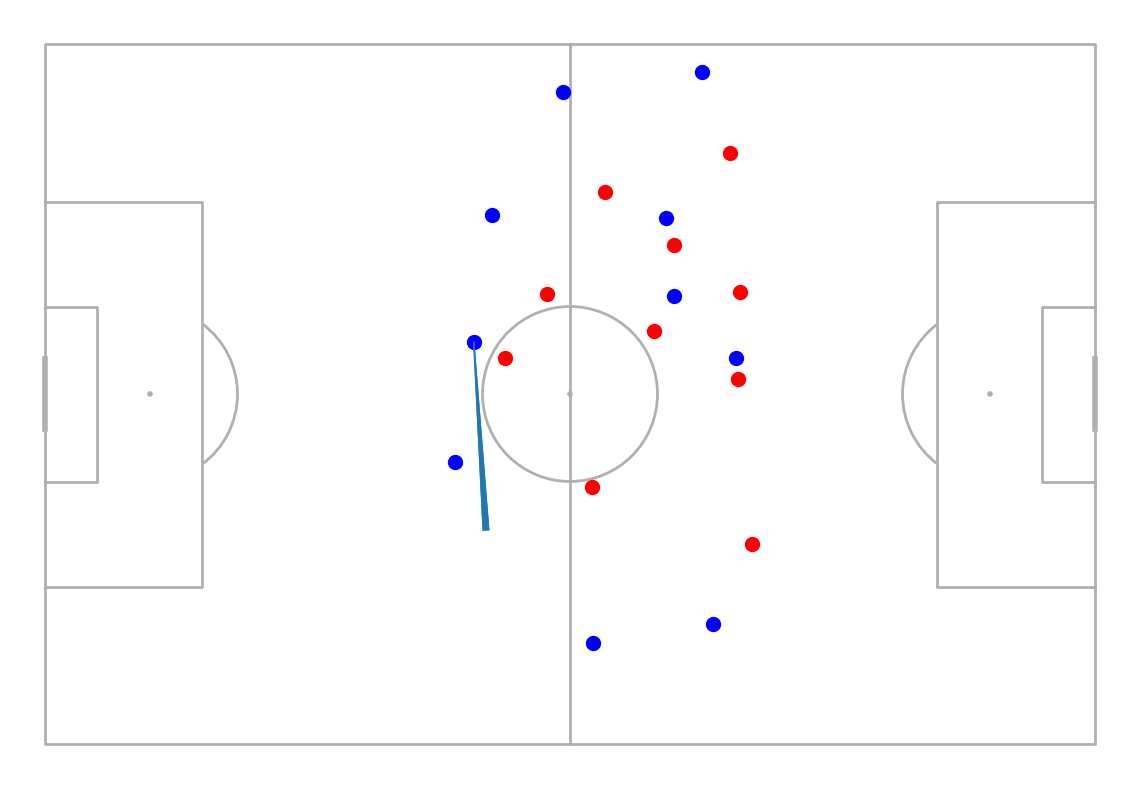

In [24]:
pitch = Pitch(pitch_type='statsbomb')
fig, ax = pitch.draw(figsize=(12,8))

row = 1
dfPlot = dfRodriPass[dfRodriPass['freeze_frame'].notna()].iloc[row]

pitch.scatter(x=dfPlot['xStart'], y=dfPlot['yStart'], ax=ax)
pitch.lines(xstart=dfPlot['xStart'], ystart=dfPlot['yStart'], xend=dfPlot['xEnd'], yend=dfPlot['yEnd'], ax=ax, comet=True)

for player in dfPlot['freeze_frame']:
    if player['teammate']:
        color = 'blue'
    else:
        color = 'red'

    pitch.scatter(x=player['location'][0], y=player['location'][1], ax=ax, c=color, s=100)

In [25]:
def update_plot(row):
    # 1. IMPORTANT: Clear the current figure to prevent stacking/not refreshing
    plt.close('all') 
    
    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#aabb97', line_color='white', linewidth=2)
    fig, ax = pitch.draw(figsize=(6, 9))
    
    # Get the data
    dfPlot = dfRodriPass.iloc[row]

    # Extract the extra info
    minute = dfPlot.get('minute', 'N/A')
    # Pressure is often a boolean (True/NaN), handle with .get() or fillna
    under_pressure = "Yes" if dfPlot.get('under_pressure') == 1 else "No"
    pass_outcome = "Complete" if pd.isna(dfPlot.get('pass_outcome')) else dfPlot['pass_outcome']

    # Calculate totals from freeze_frame
    freeze_frame = dfPlot.get('freeze_frame', [])
    teammatesCount = len([p for p in freeze_frame if p['teammate']])
    opponentsCount = len([p for p in freeze_frame if not p['teammate']])

    # Draw your pass
    pitch.scatter(x=dfPlot['xStart'], y=dfPlot['yStart'], ax=ax, c='blue', s=100, zorder=3)
    pitch.lines(xstart=dfPlot['xStart'], ystart=dfPlot['yStart'], 
                xend=dfPlot['xEnd'], yend=dfPlot['yEnd'], 
                ax=ax, comet=True, color='white', lw=3)

    # Draw freeze frame
    if 'freeze_frame' in dfPlot and isinstance(dfPlot['freeze_frame'], list):
        for player in dfPlot['freeze_frame']:
            color = 'green' if player['keeper'] else 'blue' if player['teammate'] else 'red'
            pitch.scatter(x=player['location'][0], y=player['location'][1], 
                          ax=ax, c=color, s=80, edgecolors='white')
    
    # Update Title with the info
    ax.set_title(f"{'Completed' if pd.isna(dfPlot.get('pass_outcome')) else dfPlot['pass_outcome']} pass {row} | Under Pressure: {under_pressure} | Minute: {minute}", 
                 fontsize=16, pad=10)

    # Add Legend with dynamic counts
    # We create empty scatter points just to generate the legend labels
    ax.scatter([], [], c='blue', label=f'Teammates: {teammatesCount}')
    ax.scatter([], [], c='red', label=f'Opponents: {opponentsCount}')
    ax.legend(loc='upper right', fontsize=9, frameon=True)
    
    # 4. Force display
    plt.show()
    
    # Optional: Print details below the plot for easier reading
    #print(f"{'Completed' if pd.isna(dfPlot.get('pass_outcome')) else dfPlot['pass_outcome']} pass {row} | Under Pressure: {under_pressure} | Minute: {minute}")

# Create the interactive slider
interact(update_plot, row=(0, len(dfRodriPass)-1))


interactive(children=(IntSlider(value=15, description='row', max=31), Output()), _dom_classes=('widget-interac…

<function __main__.update_plot(row)>

In [26]:
dfRodriPass.iloc[row]['freeze_frame']

[{'teammate': True,
  'actor': False,
  'keeper': False,
  'location': [46.90530142149434, 47.75402761828062]},
 {'teammate': True, 'actor': True, 'keeper': False, 'location': [49.0, 34.0]},
 {'teammate': True,
  'actor': False,
  'keeper': False,
  'location': [51.12569280787163, 19.59449235334533]},
 {'teammate': False,
  'actor': False,
  'keeper': False,
  'location': [52.604843021659946, 35.8676163311962]},
 {'teammate': False,
  'actor': False,
  'keeper': False,
  'location': [57.341713600363924, 28.62527605214452]},
 {'teammate': True,
  'actor': False,
  'keeper': False,
  'location': [59.18156886846816, 5.442174902124606]},
 {'teammate': False,
  'actor': False,
  'keeper': False,
  'location': [62.56215045246048, 50.61498988318234]},
 {'teammate': True,
  'actor': False,
  'keeper': False,
  'location': [62.59445039910907, 68.44038365280122]},
 {'teammate': False,
  'actor': False,
  'keeper': False,
  'location': [64.0566375752506, 16.954452206893393]},
 {'teammate': False,

# Events with location

In [27]:
dfRaw[dfRaw['type'] == 'Shot'].head()

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,event_uuid,visible_area,freeze_frame,player_nickname
3228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.050041,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3787ac1c-b077-4960-b717-ce3e7361f8a4,490,NaN,NaN,"[115.6, 28.4]",3943043,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,From Free Kick,Nicholas Williams Arthuer,68574.0,Left Wing,21,Spain,772,"[29cfd49e-0efa-4bf1-858f-d7d05a555507, 2ccb003...",13,NaN,Left Foot,NaN,"[116.0, 29.3]",NaN,"[{'location': [118.3, 36.0], 'player': {'id': ...",58f991d4-fef8-47d4-a7d3-bfcb2ea6b078,True,Blocked,0.068030,Normal,Open Play,NaN,NaN,NaN,NaN,NaN,Spain,772,00:11:13.568,Shot,True,3787ac1c-b077-4960-b717-ce3e7361f8a4,"[118.50661968971082, 80.0, 94.91181984601062, ...","[{'teammate': False, 'actor': False, 'keeper':...",Nico Williams
3229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.072991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c825856a-5a21-4507-b9e2-ea07b5bf4cca,500,NaN,NaN,"[112.9, 36.2]",3943043,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,From Corner,Robin Aime Robert Le Normand,22128.0,Right Center Back,22,Spain,772,"[0b354f36-d30a-4455-b47d-31594c752317, 1dd307e...",21,NaN,Right Foot,NaN,"[120.0, 29.8, 0.5]",True,"[{'location': [116.0, 40.4], 'player': {'id': ...",0c0e6467-4ce7-4a32-9de2-da2ed79db032,NaN,Off T,0.117465,Overhead Kick,Open Play,NaN,NaN,NaN,NaN,NaN,Spain,772,00:12:21.652,Shot,True,c825856a-5a21-4507-b9e2-ea07b5bf4cca,"[114.21113644631167, 80.0, 93.48173516419142, ...","[{'teammate': True, 'actor': False, 'keeper': ...",Robin Le Normand
3230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.076667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dd4098ae-cd79-4d2a-9717-e95b5fd21674,608,NaN,NaN,"[96.2, 40.8]",3943043,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,From Corner,Declan Rice,3943.0,Left Defensive Midfield,27,England,768,"[a613c9f6-ffab-44b4-bf5c-20c25175f827, cc9bfa1...",20,NaN,Right Foot,NaN,"[98.5, 40.8]",True,"[{'location': [103.6, 56.5], 'player': {'id': ...",86536f69-41fc-4585-b5ee-7a68d6dd4b32,NaN,Blocked,0.048995,Normal,Open Play,NaN,NaN,NaN,NaN,NaN,England,768,00:16:20.810,Shot,True,dd4098ae-cd79-4d2a-9717-e95b5fd21674,"[102.42608525200065, 73.14191525573858, 80.599...","[{'teammate': True, 'actor': False, 'keeper': ...",Declan Rice
3231,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.178330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [28]:
# eventType: pass, shot, carry
def PlotEventType(row, df: pd.DataFrame, eventType: str):
    # 1. IMPORTANT: Clear the current figure to prevent stacking/not refreshing
    plt.close('all') 
    
    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#aabb97', line_color='white', linewidth=2)
    fig, ax = pitch.draw(figsize=(6, 9))
    
    # Get the data
    dfFiltered = df[df['type'].str.casefold() == eventType.casefold()]
    dfFiltered[['xStart','yStart']] = pd.DataFrame(dfFiltered.location.tolist(), index=dfFiltered.index)
    #dfFiltered[['xStart', 'yStart']] = pd.DataFrame([loc if isinstance(loc, list) and len(loc) == 2
    #                                                 else [float('nan'), float('nan')] for loc in dfFiltered['location']],
    #                                                index=dfFiltered.index)
    #dfFiltered[['xEnd','yEnd']] = pd.DataFrame(dfFiltered[eventType + "_end_location"].tolist(), index=dfFiltered.index)
    # The "shot" can have a z-value sometimes
    eventType = eventType.lower()
    if eventType + "_end_location" in dfFiltered.columns:
        dfFiltered[['xEnd', 'yEnd', 'zEnd']] = pd.DataFrame(
            [loc + [float('nan')] * (3 - len(loc)) for loc in dfFiltered[eventType + "_end_location"]],
            index=dfFiltered.index)
    else:
        dfFiltered[['xEnd', 'yEnd', 'zEnd']] = float('nan')
    dfPlot = dfFiltered.iloc[row]

    # Extract the extra info
    minute = dfPlot.get('minute', 'N/A')
    # Pressure is often a boolean (True/NaN), handle with .get() or fillna
    outcome = "Complete" if pd.isna(dfPlot.get(eventType + '_outcome')) else dfPlot[eventType + '_outcome']
    playerName = dfPlot['player_nickname']

    # Calculate totals from freeze_frame
    freeze_frame = dfPlot.get('freeze_frame', [])
    if not isinstance(freeze_frame, list):
        freeze_frame = []  # Default to an empty list if it's not a valid list
    teammatesCount = len([p for p in freeze_frame if p['teammate']])
    opponentsCount = len([p for p in freeze_frame if not p['teammate']])

    # Draw your pass
    pitch.scatter(x=dfPlot['xStart'], y=dfPlot['yStart'], ax=ax, c='blue', s=100, zorder=3)
    if eventType + "_end_location" in dfFiltered.columns:
        pitch.lines(xstart=dfPlot['xStart'], ystart=dfPlot['yStart'], 
                    xend=dfPlot['xEnd'], yend=dfPlot['yEnd'], 
                    ax=ax, comet=True, color='white', lw=3)

    # Draw freeze frame
    if 'freeze_frame' in dfPlot and isinstance(dfPlot['freeze_frame'], list):
        for player in dfPlot['freeze_frame']:
            color = 'green' if player['keeper'] else 'blue' if player['teammate'] else 'red'
            pitch.scatter(x=player['location'][0], y=player['location'][1], 
                          ax=ax, c=color, s=80, edgecolors='white')
    
    # Update Title with the info
    # Check if zEnd is not NaN
    z_value = dfPlot['zEnd']
    z_text = f" | z: {z_value:.2f}" if pd.notna(z_value) else ""
    under_pressure = dfPlot['under_pressure']
    under_pressure_text = f" | Under Pressure: {under_pressure}" if pd.notna(under_pressure) else ""
    ax.set_title(f"{playerName} | {outcome} {eventType} {row}{under_pressure_text} | Minute: {minute}{z_text}", 
                 fontsize=16, pad=10)

    # Add Legend with dynamic counts
    # We create empty scatter points just to generate the legend labels
    ax.scatter([], [], c='blue', label=f'Teammates: {teammatesCount}')
    ax.scatter([], [], c='red', label=f'Opponents: {opponentsCount}')
    ax.legend(loc='upper right', fontsize=9, frameon=True)
    
    # 4. Force display
    plt.show()

# Create the interactive slider
eventType = 'Shot'
interact(PlotEventType, row=(0, len(dfRaw[dfRaw['type'] == eventType]) - 1), df=fixed(dfRaw), eventType=fixed(eventType))

interactive(children=(IntSlider(value=12, description='row', max=24), Output()), _dom_classes=('widget-interac…

<function __main__.PlotEventType(row, df: pandas.DataFrame, eventType: str)>

In [29]:
# Create a slider for selecting the index of typesWithLocation
def update_event_type(index):
    eventType = typesWithLocation[index]  # Dynamically select the event type
    interact(
        PlotEventType,
        row=(0, len(dfRaw[dfRaw['type'] == eventType]) - 1),
        df=fixed(dfRaw),
        eventType=fixed(eventType)
    )

# Create a slider for the index of typesWithLocation
interact(update_event_type, index=IntSlider(min=0, max=len(typesWithLocation) - 1, step=1, description="Event Type Index"))

interactive(children=(IntSlider(value=0, description='Event Type Index', max=20), Output()), _dom_classes=('wi…

<function __main__.update_event_type(index)>

In [30]:
# eventType: pass, shot, carry
def PlotEvents(row, df: pd.DataFrame):
    # 1. IMPORTANT: Clear the current figure to prevent stacking/not refreshing
    plt.close('all') 
    
    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#aabb97', line_color='white', linewidth=2)
    fig, ax = pitch.draw(figsize=(6, 9))
    
    # Get the data
    dfFiltered = df[(df['location'].notna()) & (df['freeze_frame'].notna())]
    dfFiltered.sort_values(by='index', inplace=True)
    dfFiltered[['xStart','yStart']] = pd.DataFrame(dfFiltered.location.tolist(), index=dfFiltered.index)
    #dfFiltered[['xStart', 'yStart']] = pd.DataFrame([loc if isinstance(loc, list) and len(loc) == 2
    #                                                 else [float('nan'), float('nan')] for loc in dfFiltered['location']],
    #                                                index=dfFiltered.index)
    #dfFiltered[['xEnd','yEnd']] = pd.DataFrame(dfFiltered[eventType + "_end_location"].tolist(), index=dfFiltered.index)
    # The "shot" can have a z-value sometimes
    if eventType + "_end_location" in dfFiltered.columns:
        dfFiltered[['xEnd', 'yEnd', 'zEnd']] = pd.DataFrame(
            [loc + [float('nan')] * (3 - len(loc)) for loc in dfFiltered[eventType + "_end_location"]],
            index=dfFiltered.index)
    else:
        dfFiltered[['xEnd', 'yEnd', 'zEnd']] = float('nan')
    dfPlot = dfFiltered.iloc[row]

    # Extract the extra info
    minute = dfPlot.get('minute', 'N/A')
    # Pressure is often a boolean (True/NaN), handle with .get() or fillna
    outcome = "Complete" if pd.isna(dfPlot.get(eventType + '_outcome')) else dfPlot[eventType + '_outcome']
    playerName = dfPlot['player_nickname']

    # Calculate totals from freeze_frame
    freeze_frame = dfPlot.get('freeze_frame', [])
    if not isinstance(freeze_frame, list):
        freeze_frame = []  # Default to an empty list if it's not a valid list
    teammatesCount = len([p for p in freeze_frame if p['teammate']])
    opponentsCount = len([p for p in freeze_frame if not p['teammate']])

    # Draw your pass
    pitch.scatter(x=dfPlot['xStart'], y=dfPlot['yStart'], ax=ax, c='blue', s=100, zorder=3)
    if eventType + "_end_location" in dfFiltered.columns:
        pitch.lines(xstart=dfPlot['xStart'], ystart=dfPlot['yStart'], 
                    xend=dfPlot['xEnd'], yend=dfPlot['yEnd'], 
                    ax=ax, comet=True, color='white', lw=3)

    # Draw freeze frame
    if 'freeze_frame' in dfPlot and isinstance(dfPlot['freeze_frame'], list):
        for player in dfPlot['freeze_frame']:
            color = 'green' if player['keeper'] else 'blue' if player['teammate'] else 'red'
            pitch.scatter(x=player['location'][0], y=player['location'][1], 
                          ax=ax, c=color, s=80, edgecolors='white')
    
    # Update Title with the info
    # Check if zEnd is not NaN
    z_value = dfPlot['zEnd']
    z_text = f" | z: {z_value:.2f}" if pd.notna(z_value) else ""
    under_pressure = dfPlot['under_pressure']
    under_pressure_text = f" | Under Pressure: {under_pressure}" if pd.notna(under_pressure) else ""
    ax.set_title(f"{playerName} | {outcome} {eventType} {row}{under_pressure_text} | Minute: {minute}{z_text}", 
                 fontsize=16, pad=10)

    # Add Legend with dynamic counts
    # We create empty scatter points just to generate the legend labels
    ax.scatter([], [], c='blue', label=f'Teammates: {teammatesCount}')
    ax.scatter([], [], c='red', label=f'Opponents: {opponentsCount}')
    ax.legend(loc='upper right', fontsize=9, frameon=True)
    
    # 4. Force display
    plt.show()

# Create the interactive slider
# Goals: 1776, 2710, 3220
interact(PlotEvents, row=(0, len(dfRaw[dfRaw['location'].notna()]) - 1), df=fixed(dfRaw))

interactive(children=(IntSlider(value=1642, description='row', max=3285), Output()), _dom_classes=('widget-int…

<function __main__.PlotEvents(row, df: pandas.DataFrame)>

In [31]:
dfLocation = dfRaw[(dfRaw['location'].notna())].sort_values(by='index')
dfGoal = dfLocation[dfLocation['shot_outcome'] == 'Goal']
dfGoal['index']

3236    1776
3247    2710
3249    3220
Name: index, dtype: int64

# Passing network graph

In [32]:
substitution_columns = [col for col in dfRaw.columns if "substitution_" in col] + ['player', 'minute', 'period']
dfRaw[dfRaw["type"] == 'Substitution'][substitution_columns]

,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,player,minute,period
3299,Injury,102.0,Martín Zubimendi Ibáñez,24921.0,Rodrigo Hernández Cascante,45,2
3300,Tactical,103.0,Ollie Watkins,4760.0,Harry Kane,60,2
3301,Tactical,103.0,Mikel Oyarzabal Ugarte,6685.0,Álvaro Borja Morata Martín,67,2
3302,Tactical,103.0,Cole Palmer,39461.0,Kobbie Mainoo,69,2
3303,Tactical,103.0,José Ignacio Fernández Iglesias,5202.0,Robin Aime Robert Le Normand,82,2
3304,Tactical,103.0,Mikel Merino Zazón,3042.0,Lamine Yamal Nasraoui Ebana,88,2
3305,Tactical,103.0,Ivan Toney,3834.0,Phil Foden,89,2


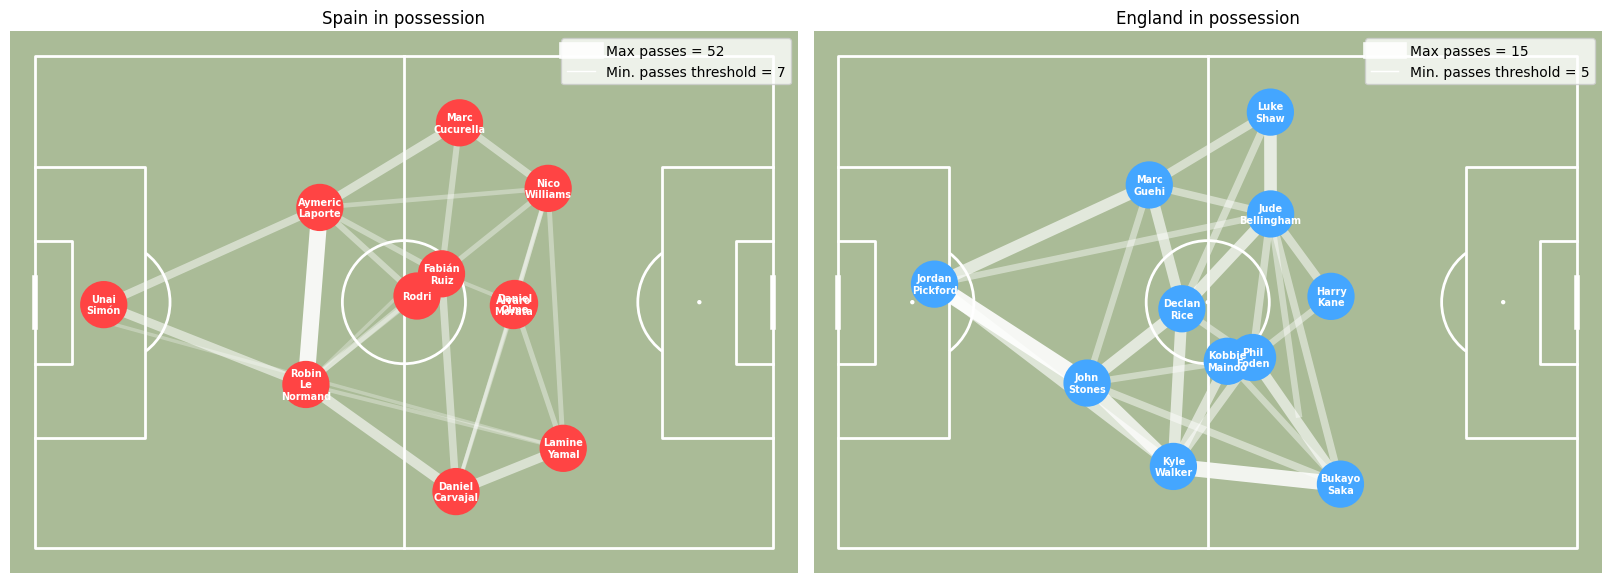

In [33]:
# Helper function to extract names from nested dictionaries
def extract_name(obj):
    if isinstance(obj, dict):
        return obj.get('name', 'Unknown')
    return str(obj)

def ShowPassingNetwork(dataframe, team: int, dfForTeam=None, minPasses=5, showPassesCount=False, ax=None):
    if not isinstance(team, int):
        raise TypeError(f"{team=} must be an int, got {type(team).__name__}")
    if not isinstance(minPasses, int):
        raise TypeError(f"{minPasses=} must be an int, got {type(minPasses).__name__}")
    if not isinstance(showPassesCount, bool):
        raise TypeError(f"{showPassesCount=} must be a bool, got {type(showPassesCount).__name__}")

    if dfForTeam is None:
        dfForTeam = dataframe.copy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))

    # Clean up data structure
    dataframe['team_name'] = dataframe['team'].apply(extract_name)
    dataframe['player_name'] = dataframe['player'].apply(lambda x: extract_name(x) if x is not None else None)
    dataframe['event_type'] = dataframe['type'].apply(extract_name)
    
    # Filter team data
    dfForTeam['team_name'] = dfForTeam['team'].apply(extract_name)
    team_name = dfForTeam['team_name'].unique()[team]
    team_events = dataframe[dataframe['team_name'] == team_name]
    passes_df = team_events[team_events['type'] == 'Pass']
    
    # Calculate average positions
    player_positions = defaultdict(list)
    for idx, event in team_events.iterrows():
        player = event.get('player_name')
        location = event.get('location')
        if player and location and isinstance(location, list) and len(location) == 2:
            player_positions[player].append(location)
            
    # Get average positions for active players
    passesThreshold = 1
    avg_positions = {}
    for player, positions in player_positions.items():
        if len(positions) >= passesThreshold:
            positions_array = np.array(positions)
            avg_x = np.mean(positions_array[:, 0])
            avg_y = np.mean(positions_array[:, 1])
            avg_positions[player] = (avg_x, avg_y)
    
    # Calculate pass connections
    pass_connections = defaultdict(int)
    for idx, pass_event in passes_df.iterrows():
        passer = pass_event.get('player_name')
        recipient_info = pass_event.get('pass_recipient')
        receiver = extract_name(recipient_info) if recipient_info else None
    
        # Check if pass was successful ([nan, 'Out', 'Incomplete', 'Unknown', 'Pass Offside'])
        passIsSuccessful = pd.notna(pass_event.get('pass_outcome'))
        passIsSuccessful = True
    
        if (passer and receiver and passIsSuccessful and
            passer in avg_positions and receiver in avg_positions):
            key = tuple(sorted((passer, receiver)))
            pass_connections[key] += 1
    
    # Filter significant connections
    significant_connections = {passerReceiver: passesCount for passerReceiver, passesCount in pass_connections.items() if passesCount >= minPasses}
    
    passesMax = max(significant_connections.values()) if significant_connections else 1
    
    # Create visualization
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#aabb97', line_color='white', linewidth=2)
    pitch.draw(ax=ax)
    
    # Draw pass connections with thickness based on frequency
    for (passer, receiver), passesCount in significant_connections.items():
        passer_pos = avg_positions[passer]
        receiver_pos = avg_positions[receiver]
    
        line_thickness = 1 + (passesCount / passesMax) * 11
        alpha = 0.2 + (passesCount / passesMax) * 0.7
    
        ax.plot([passer_pos[0], receiver_pos[0]], [passer_pos[1], receiver_pos[1]],
               color='white', linewidth=line_thickness, alpha=alpha, zorder=2)

        if showPassesCount:
            mid_x = (passer_pos[0] + receiver_pos[0]) / 2
            mid_y = (passer_pos[1] + receiver_pos[1]) / 2
            ax.text(mid_x, mid_y, str(passesCount), color='black', fontsize=9, fontweight='bold', ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8), zorder=3)
    
    # Draw player nodes (top 11 most active)
    top_players = sorted(avg_positions.items(),
                        key=lambda x: len(player_positions[x[0]]), reverse=True)[:11]
    
    for i, (player, (x, y)) in enumerate(top_players):
        circleColor = '#FF4444' if team == 0 else '#44A6FF'
        circle = plt.Circle((x, y), radius=3.5, color=circleColor,
                           edgecolor='white', linewidth=3, zorder=5)
        ax.add_patch(circle)
    
        playerNameConverted = full_to_nickname.get(player)
        playerNames = '\n'.join(playerNameConverted.split())
        ax.text(x, y, playerNames, color='white', fontweight='bold',
               ha='center', va='center', fontsize=7, zorder=6)
    
    # Show title & legend
    ax.set_title(f"{team_name} passing network",  fontsize=18, pad=10)
    max_entry = Line2D([0], [0], color='white', linewidth=1 + 11, alpha=0.9, label=f"Max passes = {passesMax}")
    minimumPassCountThreshold = Line2D([], [], color='white', linewidth=1 + (1 / passesMax),
                                       label=f"Min. passes threshold = {minPasses}")
    ax.legend(handles=[max_entry, minimumPassCountThreshold], loc='upper right')
    
    return ax


## In possession
dfSpainPossession = dfRaw[dfRaw['possession_team'] == 'Spain']
dfEnglandPossession = dfRaw[dfRaw['possession_team'] == 'England']

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

ShowPassingNetwork(dfSpainPossession, team=0, dfForTeam=dfRaw, minPasses=7, showPassesCount=False, ax=axes[0])
axes[0].set_title("Spain in possession")

ShowPassingNetwork(dfEnglandPossession, team=1, dfForTeam=dfRaw, minPasses=5, showPassesCount=False, ax=axes[1])
axes[1].set_title("England in possession")

plt.show()

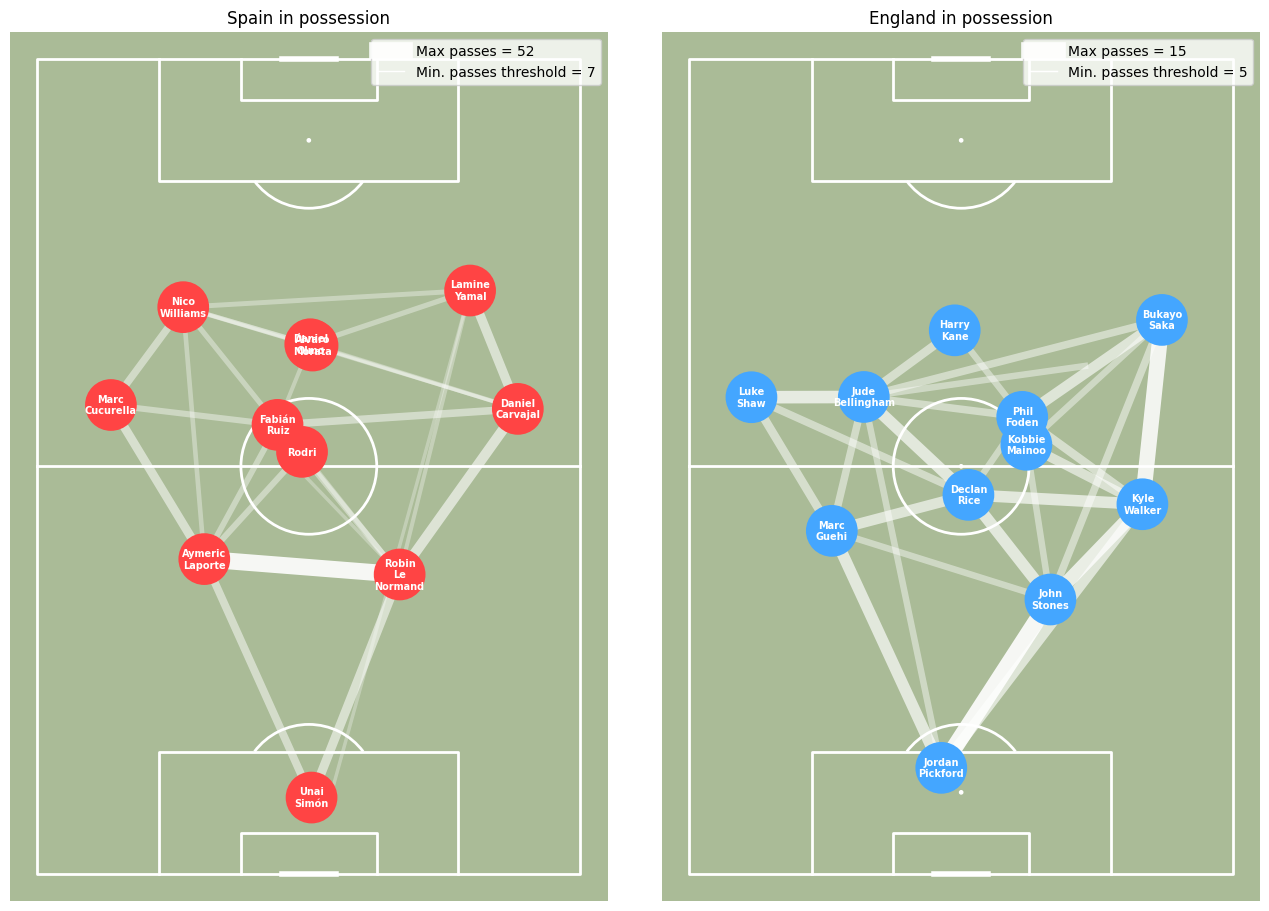

In [34]:
# Helper function to extract names from nested dictionaries
def extract_name(obj):
    if isinstance(obj, dict):
        return obj.get('name', 'Unknown')
    return str(obj)

def ShowPassingNetwork(dataframe, team: int, dfForTeam=None, minPasses=5, playersCount=11, showPassesCount=False, ax=None):
    if not isinstance(team, int):
        raise TypeError(f"{team=} must be an int, got {type(team).__name__}")
    if not isinstance(minPasses, int):
        raise TypeError(f"{minPasses=} must be an int, got {type(minPasses).__name__}")
    if not isinstance(showPassesCount, bool):
        raise TypeError(f"{showPassesCount=} must be a bool, got {type(showPassesCount).__name__}")

    if dfForTeam is None:
        dfForTeam = dataframe.copy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))

    # Clean up data structure
    dataframe['team_name'] = dataframe['team'].apply(extract_name)
    dataframe['player_name'] = dataframe['player'].apply(lambda x: extract_name(x) if x is not None else None)
    dataframe['event_type'] = dataframe['type'].apply(extract_name)
    
    # Filter team data
    dfForTeam['team_name'] = dfForTeam['team'].apply(extract_name)
    team_name = dfForTeam['team_name'].unique()[team]
    team_events = dataframe[dataframe['team_name'] == team_name]
    passes_df = team_events[team_events['type'] == 'Pass']
    
    # Calculate average positions
    player_positions = defaultdict(list)
    for idx, event in team_events.iterrows():
        player = event.get('player_name')
        location = event.get('location')
        if player and location and isinstance(location, list) and len(location) == 2:
            player_positions[player].append(location)
            
    # Get average positions for active players
    passesThreshold = 1
    avg_positions = {}
    for player, positions in player_positions.items():
        if len(positions) >= passesThreshold:
            positions_array = np.array(positions)
            avg_x = np.mean(positions_array[:, 0])
            avg_y = np.mean(positions_array[:, 1])
            avg_positions[player] = (avg_x, avg_y)
    
    # Calculate pass connections
    pass_connections = defaultdict(int)
    for idx, pass_event in passes_df.iterrows():
        passer = pass_event.get('player_name')
        recipient_info = pass_event.get('pass_recipient')
        receiver = extract_name(recipient_info) if recipient_info else None
    
        # Check if pass was successful ([nan, 'Out', 'Incomplete', 'Unknown', 'Pass Offside'])
        passIsSuccessful = pd.notna(pass_event.get('pass_outcome'))
        passIsSuccessful = True
    
        if (passer and receiver and passIsSuccessful and
            passer in avg_positions and receiver in avg_positions):
            key = tuple(sorted((passer, receiver)))
            pass_connections[key] += 1
    
    # Filter significant connections
    significant_connections = {passerReceiver: passesCount for passerReceiver, passesCount in pass_connections.items() if passesCount >= minPasses}
    
    passesMax = max(significant_connections.values()) if significant_connections else 1
    
    # Create visualization
    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#aabb97', line_color='white', linewidth=2)
    pitch.draw(ax=ax)
    
    # Draw pass connections with thickness based on frequency
    for (passer, receiver), passesCount in significant_connections.items():
        passer_pos = avg_positions[passer]
        receiver_pos = avg_positions[receiver]
    
        line_thickness = 1 + (passesCount / passesMax) * 11
        alpha = 0.2 + (passesCount / passesMax) * 0.7
    
        ax.plot([passer_pos[1], receiver_pos[1]], [passer_pos[0], receiver_pos[0]],
               color='white', linewidth=line_thickness, alpha=alpha, zorder=2)

        if showPassesCount:
            mid_x = (passer_pos[0] + receiver_pos[0]) / 2
            mid_y = (passer_pos[1] + receiver_pos[1]) / 2
            ax.text(mid_y, mid_y, str(passesCount), color='black', fontsize=9, fontweight='bold', ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8), zorder=3)
    
    # Draw player nodes (top 11 most active)
    top_players = sorted(avg_positions.items(),
                        key=lambda x: len(player_positions[x[0]]), reverse=True)[:playersCount]
    
    for i, (player, (x, y)) in enumerate(top_players):
        circleColor = '#FF4444' if team == 0 else '#44A6FF'
        circle = plt.Circle((y, x), radius=3.5, color=circleColor,
                           edgecolor='white', linewidth=3, zorder=5)
        ax.add_patch(circle)
    
        playerNameConverted = full_to_nickname.get(player)
        playerNames = '\n'.join(playerNameConverted.split())
        ax.text(y, x, playerNames, color='white', fontweight='bold',
               ha='center', va='center', fontsize=7, zorder=6)
    
    # Show title & legend
    ax.set_title(f"{team_name} passing network",  fontsize=18, pad=10)
    max_entry = Line2D([0], [0], color='white', linewidth=1 + 11, alpha=0.9, label=f"Max passes = {passesMax}")
    minimumPassCountThreshold = Line2D([], [], color='white', linewidth=1 + (1 / passesMax),
                                       label=f"Min. passes threshold = {minPasses}")
    ax.legend(handles=[max_entry, minimumPassCountThreshold], loc='upper right')
    
    return ax


## In possession
dfSpainPossession = dfRaw[dfRaw['possession_team'] == 'Spain']
dfEnglandPossession = dfRaw[dfRaw['possession_team'] == 'England']

fig, axes = plt.subplots(1, 2, figsize=(13, 9), constrained_layout=True)

ShowPassingNetwork(dfSpainPossession, team=0, dfForTeam=dfRaw, minPasses=7, showPassesCount=False, ax=axes[0])
axes[0].set_title("Spain in possession")

ShowPassingNetwork(dfEnglandPossession, team=1, dfForTeam=dfRaw, minPasses=5, showPassesCount=False, ax=axes[1])
axes[1].set_title("England in possession")

plt.show()

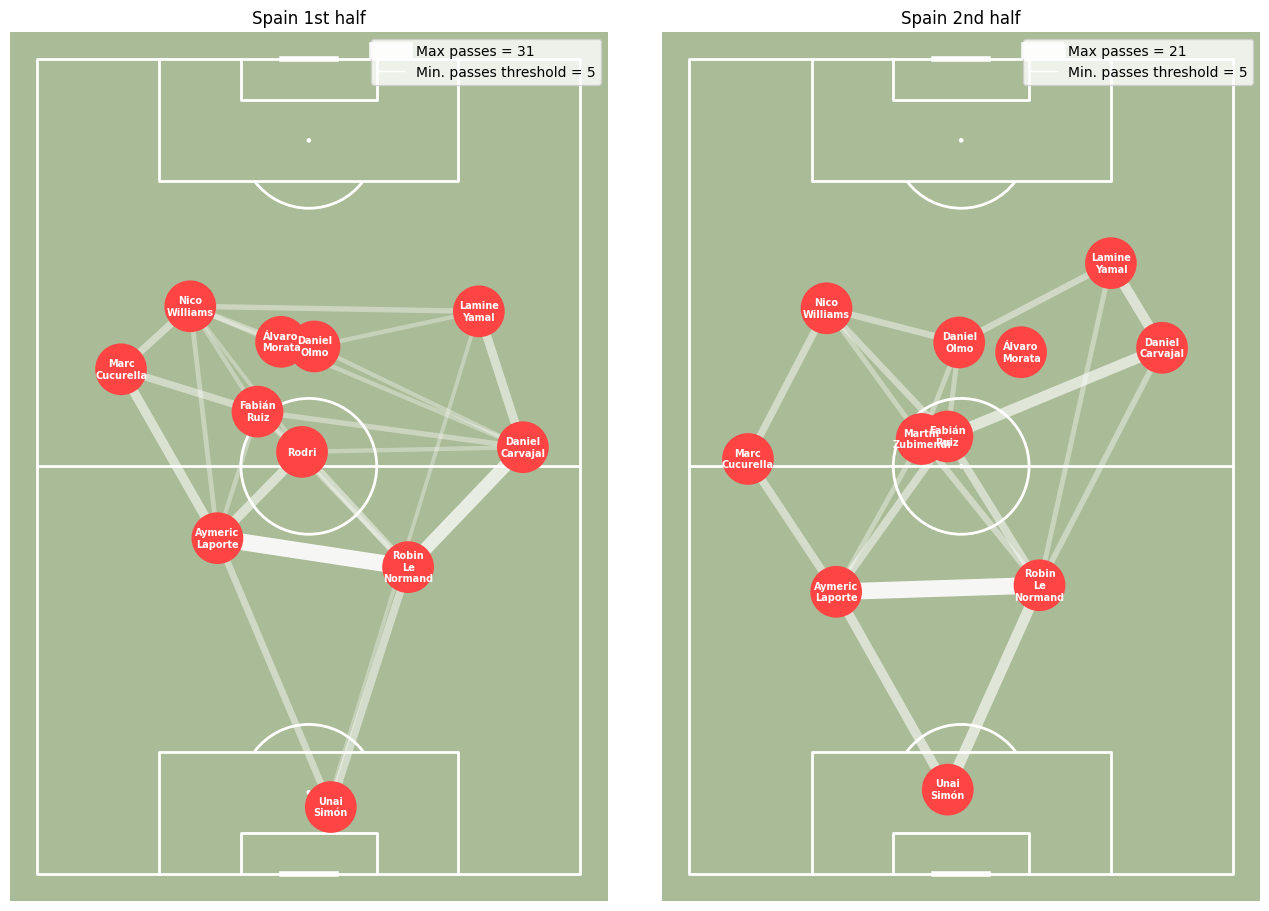

In [35]:
dfSpainPossession1 = dfRaw[(dfRaw['possession_team'] == 'Spain') & (dfRaw['period'] == 1)]
dfSpainPossession2 = dfRaw[(dfRaw['possession_team'] == 'Spain') & (dfRaw['period'] == 2)]

fig, axes = plt.subplots(1, 2, figsize=(13, 9), constrained_layout=True)

ShowPassingNetwork(dfSpainPossession1, team=0, dfForTeam=dfRaw, minPasses=5, showPassesCount=False, ax=axes[0])
axes[0].set_title("Spain 1st half")

ShowPassingNetwork(dfSpainPossession2, team=0, dfForTeam=dfRaw, minPasses=5, showPassesCount=False, ax=axes[1])
axes[1].set_title("Spain 2nd half")

plt.show()

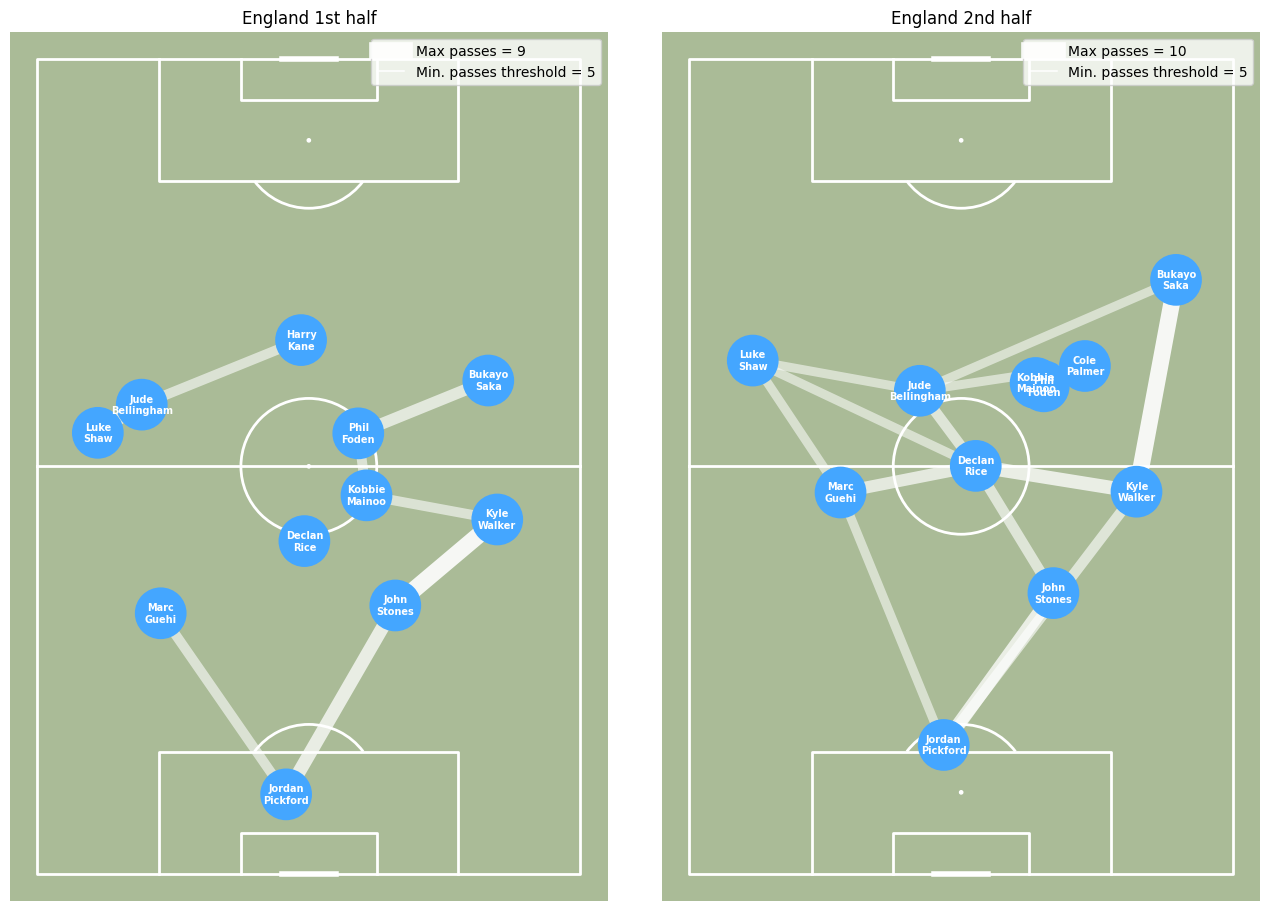

In [36]:
dfEnglandPossession1 = dfRaw[(dfRaw['possession_team'] == 'England') & (dfRaw['period'] == 1)]
dfEnglandPossession2 = dfRaw[(dfRaw['possession_team'] == 'England') & (dfRaw['period'] == 2)]

fig, axes = plt.subplots(1, 2, figsize=(13, 9), constrained_layout=True)

ShowPassingNetwork(dfEnglandPossession1, team=1, dfForTeam=dfRaw, minPasses=5, showPassesCount=False, ax=axes[0])
axes[0].set_title("England 1st half")

ShowPassingNetwork(dfEnglandPossession2, team=1, dfForTeam=dfRaw, minPasses=5, showPassesCount=False, ax=axes[1])
axes[1].set_title("England 2nd half")

plt.show()

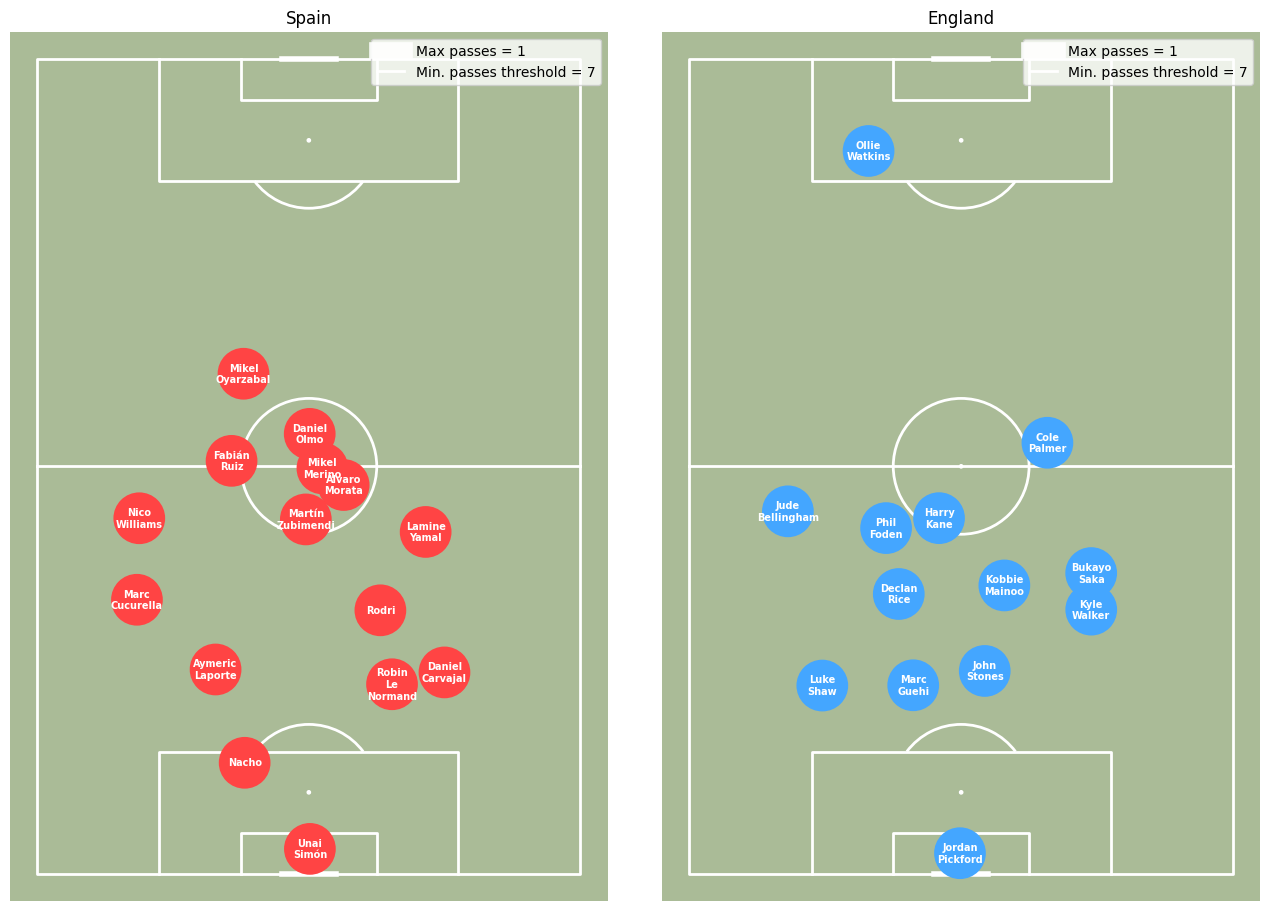

In [37]:
## Out of possession
dfSpainDefending= dfRaw[dfRaw['possession_team'] == 'England']
dfEnglandDefending = dfRaw[dfRaw['possession_team'] == 'Spain']

fig, axes = plt.subplots(1, 2, figsize=(13, 9), constrained_layout=True)

ShowPassingNetwork(dfSpainDefending, team=0, dfForTeam=dfRaw, minPasses=7, playersCount=15, showPassesCount=False, ax=axes[0])
axes[0].set_title("Spain")

ShowPassingNetwork(dfEnglandDefending, team=1, dfForTeam=dfRaw, minPasses=7, playersCount=15, showPassesCount=False, ax=axes[1])
axes[1].set_title("England")

plt.show()

## Horizontal passing map with numbers

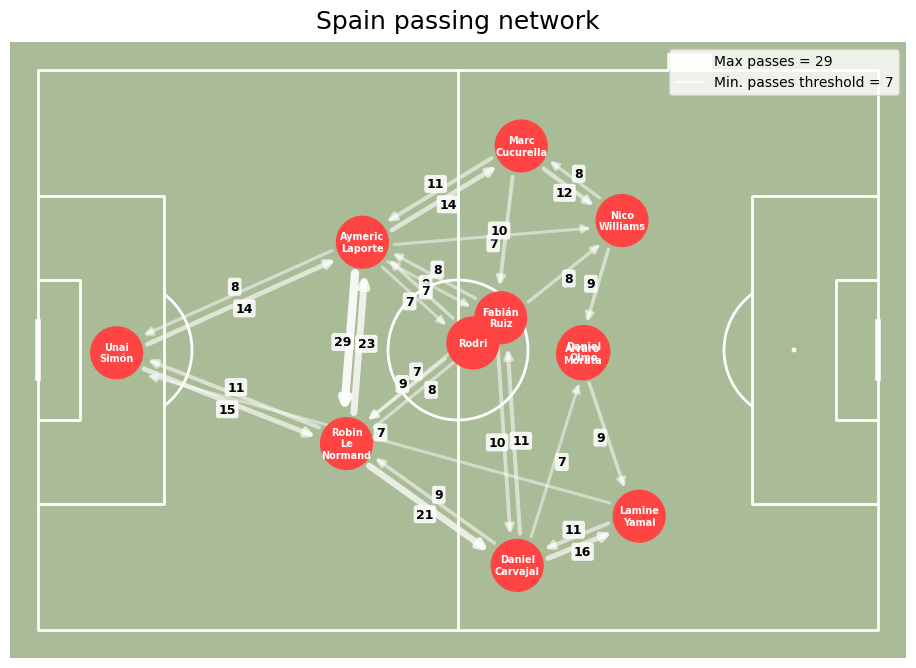

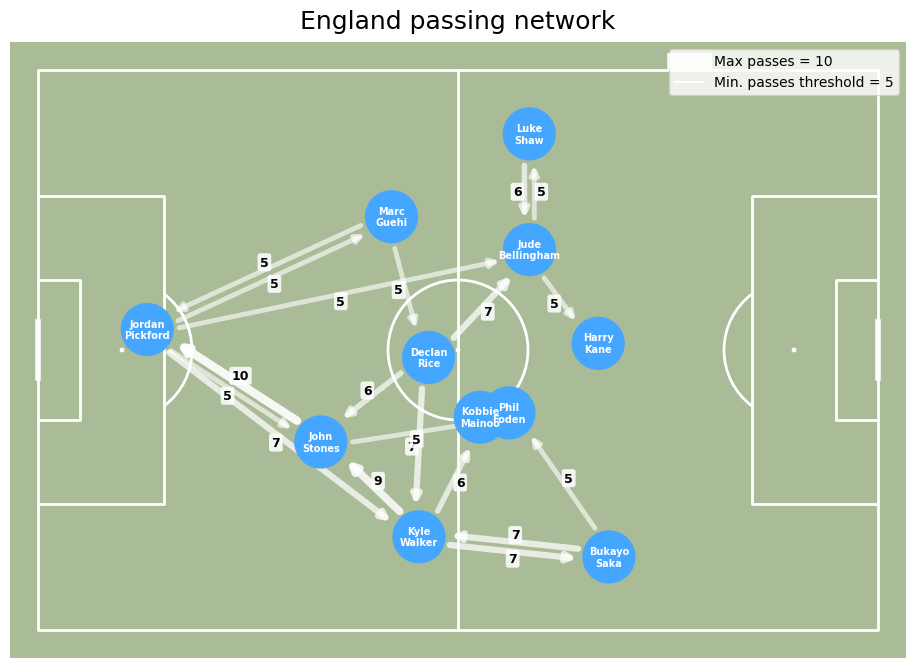

In [38]:
# Helper function to extract names from nested dictionaries
def extract_name(obj):
    if isinstance(obj, dict):
        return obj.get('name', 'Unknown')
    return str(obj)

def ShowDirectionalPassingNetwork(dataframe, team: int, dfForTeam=None, row_filter=None, minPasses=5, showPassesCount=True, ax=None):
    if not isinstance(team, int):
        raise TypeError(f"{team=} must be an int, got {type(team).__name__}")
    if not isinstance(minPasses, int):
        raise TypeError(f"{minPasses=} must be an int, got {type(minPasses).__name__}")
    if not isinstance(showPassesCount, bool):
        raise TypeError(f"{showPassesCount=} must be a bool, got {type(showPassesCount).__name__}")
        
    if dfForTeam is None:
        dfForTeam = dataframe.copy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))

    node_radius = 3.5
    gap = 0.6
    shorten = node_radius + gap         # trim near each node
    arrow_offset = 0.7                  # separation between the two arrows
    label_offset = 2.0                  # how far labels sit from each arrow

    # Clean up data structure
    dataframe['team_name'] = dataframe['team'].apply(extract_name)
    dataframe['player_name'] = dataframe['player'].apply(lambda x: extract_name(x) if x is not None else None)
    dataframe['event_type'] = dataframe['type'].apply(extract_name)

    # Filter team data
    dfForTeam['team_name'] = dfForTeam['team'].apply(extract_name)
    team_name = dfForTeam['team_name'].unique()[team]
    team_events = dataframe[dataframe['team_name'] == team_name] 
    passes_df = team_events[team_events['type'] == 'Pass']
    
    # Calculate average positions
    player_positions = defaultdict(list)
    for idx, event in team_events.iterrows():
        player = event.get('player_name')
        location = event.get('location')
        if player and location and isinstance(location, list) and len(location) == 2:
            player_positions[player].append(location)
            
    # Get average positions for active players
    passesThreshold = 1
    avg_positions = {}
    for player, positions in player_positions.items():
        if len(positions) >= passesThreshold:
            positions_array = np.array(positions)
            avg_x = np.mean(positions_array[:, 0])
            avg_y = np.mean(positions_array[:, 1])
            avg_positions[player] = (avg_x, avg_y)
    
    # Calculate pass connections
    pass_connections = defaultdict(int)
    for idx, pass_event in passes_df.iterrows():
        passer = pass_event.get('player_name')
        recipient_info = pass_event.get('pass_recipient')
        receiver = extract_name(recipient_info) if recipient_info else None
    
        # Check if pass was successful ([nan, 'Out', 'Incomplete', 'Unknown', 'Pass Offside'])
        passIsSuccessful = pd.notna(pass_event.get('pass_outcome'))
        passIsSuccessful = True
    
        if (passer and receiver and passIsSuccessful and
            passer in avg_positions and receiver in avg_positions):
            pass_connections[(passer, receiver)] += 1

    
    merged_connections = defaultdict(int)
    for (passer, receiver), count in pass_connections.items():
        key = tuple(sorted((passer, receiver)))  # ('A','B') == ('B','A')
        merged_connections[key] += count
    
    # Filter significant connections
    significant_connections = {passerReceiver: passesCount for passerReceiver, passesCount in pass_connections.items() if passesCount >= minPasses}
    
    passesMax = max(significant_connections.values()) if significant_connections else 1
    
    # Create visualization
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#aabb97', line_color='white', linewidth=2)
    pitch.draw(ax=ax)
    
    # Draw pass connections with thickness based on frequency
    handled = set()
    
    for (passer, receiver), count_ab in significant_connections.items():
        if (receiver, passer) in handled:
            continue
    
        pos_a = np.array(avg_positions[passer], dtype=float)
        pos_b = np.array(avg_positions[receiver], dtype=float)
        vec = pos_b - pos_a
        dist = np.linalg.norm(vec)
        if dist <= 2 * shorten:
            continue  # too close
    
        direction = vec / dist
        base_start = pos_a + direction * shorten
        base_end = pos_b - direction * shorten
        segment = base_end - base_start
        seg_len = np.linalg.norm(segment)
        perp = np.array([-segment[1], segment[0]]) / seg_len

        scale = 5
        # forward arrow (passer -> receiver)
        start_ab = base_start + perp * arrow_offset
        end_ab = base_end + perp * arrow_offset
        width_ab = 1 + (count_ab / passesMax) * scale
        alpha_ab = 0.35 + (count_ab / passesMax) * 0.55
        arrow_ab = FancyArrowPatch(
            start_ab,
            end_ab,
            arrowstyle='-|>',
            mutation_scale=12,
            linewidth=width_ab,
            color='white',
            alpha=alpha_ab,
            zorder=4,
        )
        ax.add_patch(arrow_ab)
    
        # reverse arrow (receiver -> passer)
        count_ba = significant_connections.get((receiver, passer), 0)
        if count_ba:
            start_ba = base_end - perp * arrow_offset
            end_ba = base_start - perp * arrow_offset
            width_ba = 1 + (count_ba / passesMax) * scale
            alpha_ba = 0.35 + (count_ba / passesMax) * 0.55
            arrow_ba = FancyArrowPatch(
                start_ba,
                end_ba,
                arrowstyle='-|>',
                mutation_scale=12,
                linewidth=width_ba,
                color='white',
                alpha=alpha_ba,
                zorder=4,
            )
            ax.add_patch(arrow_ba)
    
        # labels aligned with corresponding arrows
        bbox = dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.85)
        mid_ab = (start_ab + end_ab) / 2
        ax.text(* (mid_ab + perp * label_offset / 2), str(count_ab),
                ha='center', va='center', fontsize=9, fontweight='bold',
                color='black', bbox=bbox, zorder=5)
    
        if count_ba:
            mid_ba = (start_ba + end_ba) / 2
            ax.text(* (mid_ba - perp * label_offset / 2), str(count_ba),
                    ha='center', va='center', fontsize=9, fontweight='bold',
                    color='black', bbox=bbox, zorder=5)
    
        handled.update({(passer, receiver), (receiver, passer)})    
        
    # Draw player nodes (top 11 most active)
    top_players = sorted(avg_positions.items(),
                        key=lambda x: len(player_positions[x[0]]), reverse=True)[:11]
    
    for i, (player, (x, y)) in enumerate(top_players):
        circleColor = '#FF4444' if team == 0 else '#44A6FF'
        circle = plt.Circle((x, y), radius=3.5, color=circleColor,
                           edgecolor='white', linewidth=3, zorder=5)
        ax.add_patch(circle)
    
        playerNameConverted = full_to_nickname.get(player)
        playerNames = '\n'.join(playerNameConverted.split())
        ax.text(x, y, playerNames, color='white', fontweight='bold',
               ha='center', va='center', fontsize=7, zorder=6)
        
    # Show title & legend
    ax.set_title(f"{team_name} passing network",  fontsize=18, pad=10)
    max_entry = Line2D([0], [0], color='white', linewidth=1 + 11, alpha=0.9, label=f"Max passes = {passesMax}")
    minimumPassCountThreshold = Line2D([], [], color='white', linewidth=1 + (1 / passesMax) * scale,
                                       label=f"Min. passes threshold = {minPasses}")
    ax.legend(handles=[max_entry, minimumPassCountThreshold], loc='upper right')
    
    return (ax, pass_connections, merged_connections)



dfSpainPossession = dfRaw[dfRaw['possession_team'] == 'Spain']
dfEnglandPossession = dfRaw[dfRaw['possession_team'] == 'England']
    
(networkPlot, passConnections, mergedPassConnections) = ShowDirectionalPassingNetwork(dfSpainPossession, team=0, dfForTeam=dfRaw, minPasses=7, showPassesCount=False, ax=None)
(networkPlot, passConnections, mergedPassConnections) = ShowDirectionalPassingNetwork(dfEnglandPossession, team=1, dfForTeam=dfRaw, minPasses=5, showPassesCount=False, ax=None)

## Vertical passing map with numbers

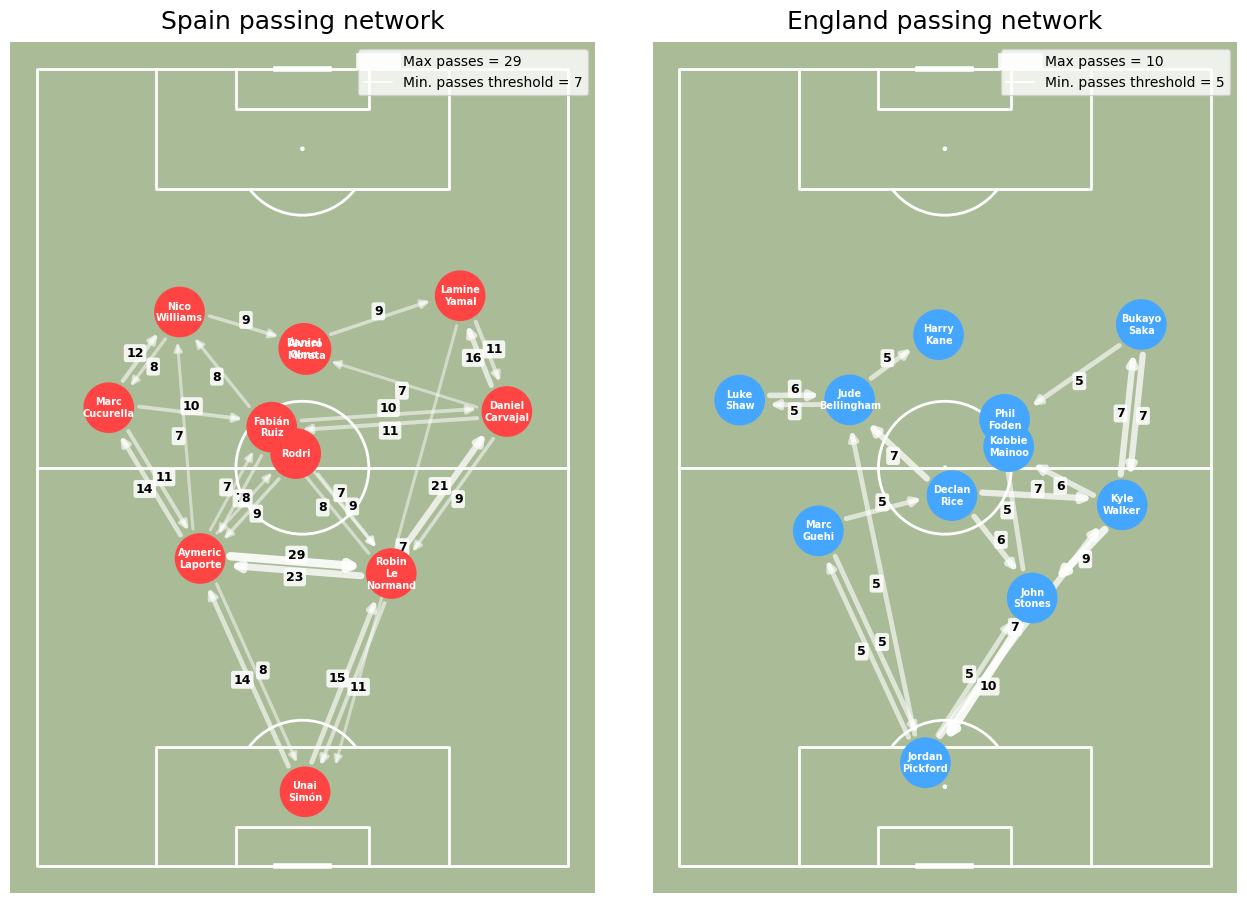

In [39]:
# Helper function to extract names from nested dictionaries
def extract_name(obj):
    if isinstance(obj, dict):
        return obj.get('name', 'Unknown')
    return str(obj)

def ShowDirectionalPassingNetwork(dataframe, team: int, dfForTeam=None, row_filter=None, minPasses=5, showPassesCount=True, ax=None):
    if not isinstance(team, int):
        raise TypeError(f"{team=} must be an int, got {type(team).__name__}")
    if not isinstance(minPasses, int):
        raise TypeError(f"{minPasses=} must be an int, got {type(minPasses).__name__}")
    if not isinstance(showPassesCount, bool):
        raise TypeError(f"{showPassesCount=} must be a bool, got {type(showPassesCount).__name__}")
        
    if dfForTeam is None:
        dfForTeam = dataframe.copy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(18, 12))

    node_radius = 3.5
    gap = 0.6
    shorten = node_radius + gap         # trim near each node
    arrow_offset = 0.7                  # separation between the two arrows
    label_offset = 2.0                  # how far labels sit from each arrow

    # Clean up data structure
    dataframe['team_name'] = dataframe['team'].apply(extract_name)
    dataframe['player_name'] = dataframe['player'].apply(lambda x: extract_name(x) if x is not None else None)
    dataframe['event_type'] = dataframe['type'].apply(extract_name)

    # Filter team data
    dfForTeam['team_name'] = dfForTeam['team'].apply(extract_name)
    team_name = dfForTeam['team_name'].unique()[team]
    team_events = dataframe[dataframe['team_name'] == team_name] 
    passes_df = team_events[team_events['type'] == 'Pass']
    
    # Calculate average positions
    player_positions = defaultdict(list)
    for idx, event in team_events.iterrows():
        player = event.get('player_name')
        location = event.get('location')
        if player and location and isinstance(location, list) and len(location) == 2:
            player_positions[player].append(location)
            
    # Get average positions for active players
    passesThreshold = 1
    avg_positions = {}
    for player, positions in player_positions.items():
        if len(positions) >= passesThreshold:
            positions_array = np.array(positions)
            avg_x = np.mean(positions_array[:, 0])
            avg_y = np.mean(positions_array[:, 1])
            avg_positions[player] = (avg_y, avg_x)
    
    # Calculate pass connections
    pass_connections = defaultdict(int)
    for idx, pass_event in passes_df.iterrows():
        passer = pass_event.get('player_name')
        recipient_info = pass_event.get('pass_recipient')
        receiver = extract_name(recipient_info) if recipient_info else None
    
        # Check if pass was successful ([nan, 'Out', 'Incomplete', 'Unknown', 'Pass Offside'])
        passIsSuccessful = pd.notna(pass_event.get('pass_outcome'))
        passIsSuccessful = True
    
        if (passer and receiver and passIsSuccessful and
            passer in avg_positions and receiver in avg_positions):
            pass_connections[(passer, receiver)] += 1

    
    merged_connections = defaultdict(int)
    for (passer, receiver), count in pass_connections.items():
        key = tuple(sorted((passer, receiver)))  # ('A','B') == ('B','A')
        merged_connections[key] += count
    
    # Filter significant connections
    significant_connections = {passerReceiver: passesCount for passerReceiver, passesCount in pass_connections.items() if passesCount >= minPasses}
    
    passesMax = max(significant_connections.values()) if significant_connections else 1
    
    # Create visualization
    pitch = VerticalPitch(pitch_type='statsbomb', pitch_color='#aabb97', line_color='white', linewidth=2)
    pitch.draw(figsize=(8, 12), ax=ax)
    
    # Draw pass connections with thickness based on frequency
    handled = set()
    
    for (passer, receiver), count_ab in significant_connections.items():
        if (receiver, passer) in handled:
            continue
    
        pos_a = np.array(avg_positions[passer], dtype=float)
        pos_b = np.array(avg_positions[receiver], dtype=float)
        vec = pos_b - pos_a
        dist = np.linalg.norm(vec)
        if dist <= 2 * shorten:
            continue  # too close
    
        direction = vec / dist
        base_start = pos_a + direction * shorten
        base_end = pos_b - direction * shorten
        segment = base_end - base_start
        seg_len = np.linalg.norm(segment)
        perp = np.array([-segment[1], segment[0]]) / seg_len

        scale = 5
        # forward arrow (passer -> receiver)
        start_ab = base_start + perp * arrow_offset
        end_ab = base_end + perp * arrow_offset
        width_ab = 1 + (count_ab / passesMax) * scale
        alpha_ab = 0.35 + (count_ab / passesMax) * 0.55
        arrow_ab = FancyArrowPatch(
            start_ab,
            end_ab,
            arrowstyle='-|>',
            mutation_scale=12,
            linewidth=width_ab,
            color='white',
            alpha=alpha_ab,
            zorder=4,
        )
        ax.add_patch(arrow_ab)
    
        # reverse arrow (receiver -> passer)
        count_ba = significant_connections.get((receiver, passer), 0)
        if count_ba:
            start_ba = base_end - perp * arrow_offset
            end_ba = base_start - perp * arrow_offset
            width_ba = 1 + (count_ba / passesMax) * scale
            alpha_ba = 0.35 + (count_ba / passesMax) * 0.55
            arrow_ba = FancyArrowPatch(
                start_ba,
                end_ba,
                arrowstyle='-|>',
                mutation_scale=12,
                linewidth=width_ba,
                color='white',
                alpha=alpha_ba,
                zorder=4,
            )
            ax.add_patch(arrow_ba)
    
        # labels aligned with corresponding arrows
        bbox = dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.85)
        mid_ab = (start_ab + end_ab) / 2
        ax.text(* (mid_ab + perp * label_offset / 2), str(count_ab),
                ha='center', va='center', fontsize=9, fontweight='bold',
                color='black', bbox=bbox, zorder=5)
    
        if count_ba:
            mid_ba = (start_ba + end_ba) / 2
            ax.text(* (mid_ba - perp * label_offset / 2), str(count_ba),
                    ha='center', va='center', fontsize=9, fontweight='bold',
                    color='black', bbox=bbox, zorder=5)
    
        handled.update({(passer, receiver), (receiver, passer)})    
        
    # Draw player nodes (top 11 most active)
    top_players = sorted(avg_positions.items(),
                        key=lambda x: len(player_positions[x[0]]), reverse=True)[:11]
    
    for i, (player, (x, y)) in enumerate(top_players):
        circleColor = '#FF4444' if team == 0 else '#44A6FF'
        circle = plt.Circle((x, y), radius=3.5, color=circleColor,
                           edgecolor='white', linewidth=3, zorder=5)
        ax.add_patch(circle)
    
        playerNameConverted = full_to_nickname.get(player)
        playerNames = '\n'.join(playerNameConverted.split())
        ax.text(x, y, playerNames, color='white', fontweight='bold',
               ha='center', va='center', fontsize=7, zorder=6)
        
    # Show title & legend
    ax.set_title(f"{team_name} passing network",  fontsize=18, pad=10)
    max_entry = Line2D([0], [0], color='white', linewidth=1 + 11, alpha=0.9, label=f"Max passes = {passesMax}")
    minimumPassCountThreshold = Line2D([], [], color='white', linewidth=1 + (1 / passesMax) * scale,
                                       label=f"Min. passes threshold = {minPasses}")
    ax.legend(handles=[max_entry, minimumPassCountThreshold], loc='upper right')
    
    return (ax, pass_connections, merged_connections)



dfSpainPossession = dfRaw[dfRaw['possession_team'] == 'Spain']
dfEnglandPossession = dfRaw[dfRaw['possession_team'] == 'England']

fig, axes = plt.subplots(1, 2, figsize=(13, 9), constrained_layout=True)

(networkPlot, passConnections, mergedPassConnections) = ShowDirectionalPassingNetwork(dfSpainPossession, team=0, dfForTeam=dfRaw, minPasses=7, showPassesCount=False, ax=axes[0])
(networkPlot, passConnections, mergedPassConnections) = ShowDirectionalPassingNetwork(dfEnglandPossession, team=1, dfForTeam=dfRaw, minPasses=5, showPassesCount=False, ax=axes[1])

plt.tight_layout()
plt.show()

In [40]:
#passConnections
#mergedPassConnections
#significantConnections = {passerReceiver: passesCount for passerReceiver, passesCount in passConnections.items() if passesCount >= 5}
#significantConnections = {passerReceiver: passesCount for passerReceiver, passesCount in mergedPassConnections.items() if passesCount >= 5}
#{passerReceiver: passesCount for passerReceiver, passesCount in passConnections.items() if passesCount >= 5}
{passerReceiver: passesCount for passerReceiver, passesCount in mergedPassConnections.items() if passesCount >= 10}

{('Declan Rice', 'Jude Bellingham'): 10,
 ('Jude Bellingham', 'Luke Shaw'): 11,
 ('John Stones', 'Kyle Walker'): 12,
 ('John Stones', 'Jordan Pickford'): 15,
 ('Bukayo Saka', 'Kyle Walker'): 14,
 ('Declan Rice', 'Kyle Walker'): 10,
 ('Declan Rice', 'John Stones'): 10,
 ('Jordan Pickford', 'Marc Guehi'): 10}

In [41]:
(_, passConnections, mergedPassConnections) = ShowDirectionalPassingNetwork(dfSpainPossession, team=0, dfForTeam=dfRaw, minPasses=7, showPassesCount=False, ax=axes[0])
{k: v for k, v in mergedPassConnections.items() if 'Morata' in str(k) and v >= 7}


{('Daniel Carvajal Ramos', 'Álvaro Borja Morata Martín'): 8,
 ('Daniel Olmo Carvajal', 'Álvaro Borja Morata Martín'): 8,
 ('Nicholas Williams Arthuer', 'Álvaro Borja Morata Martín'): 11}

In [42]:
(_, passConnections, mergedPassConnections) = ShowDirectionalPassingNetwork(dfSpainPossession, team=0, dfForTeam=dfRaw, minPasses=7, showPassesCount=False, ax=axes[0])
{k: v for k, v in mergedPassConnections.items() if 'Olmo' in str(k) and v >= 7}

{('Daniel Carvajal Ramos', 'Daniel Olmo Carvajal'): 10,
 ('Daniel Olmo Carvajal', 'Álvaro Borja Morata Martín'): 8,
 ('Daniel Olmo Carvajal', 'Nicholas Williams Arthuer'): 10,
 ('Daniel Olmo Carvajal', 'Fabián Ruiz Peña'): 9,
 ('Daniel Olmo Carvajal', 'Lamine Yamal Nasraoui Ebana'): 13}

# Event locations

In [43]:
def ShowEventTypeScatter(dataframe, team: int, event: int | None = None, ax=None):
    if not isinstance(team, int):
        raise TypeError(f"{team=} must be an int, got {type(team).__name__}")
    if event is not None and not isinstance(event, str):
        raise TypeError(f"{event=} must be a string, got {type(event).__name__}")

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))

    # draw pitch background
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#aabb97',
                  line_color='white', linewidth=2)
    pitch.draw(ax=ax)

    dataframe['event_name'] = dataframe['type'].apply(
        lambda x: x['name'] if isinstance(x, dict) else str(x)
    )
    dataframe['team_name'] = dataframe['team'].apply(
        lambda x: x['name'] if isinstance(x, dict) else str(x)
    )

    team_name = dataframe['team_name'].unique()[team]
    team_df = dataframe[dataframe['team_name'] == team_name]

    event_colors = {
        'Pass': 'blue', 'Ball Receipt*': 'green', 'Carry': 'orange',
        'Pressure': 'red', 'Ball Recovery': 'purple', 'Clearance': 'brown'
    }
    event_markers = {
        'Pass': 'o', 'Ball Receipt*': 's', 'Carry': '^',
        'Pressure': 'x', 'Ball Recovery': 'd', 'Clearance': 'v'
    }

    unique_events = sorted(team_df['event_name'].unique())
    if not unique_events:
        return ax

    if event is None:
        target_events = unique_events
        legend_suffix = "All events"
    else:
        if event not in unique_events:
            raise ValueError(f"{event=} not found for team {team_name}")
        target_events = [event]
        legend_suffix = event
        
    handles, labels = ax.get_legend_handles_labels()

    for event_type in target_events:
        subset = team_df[team_df['event_name'] == event_type]
        color = event_colors.get(event_type, 'gray')
        marker = event_markers.get(event_type, 'o')

        # only add legend entry once per event_type
        add_label = event_type not in labels
        for _, row in subset.iterrows():
            location = row['location']
            if isinstance(location, (list, tuple)) and len(location) == 2:
                x, y = location
                ax.scatter(
                    x, y,
                    c=color,
                    marker=marker,
                    s=50,
                    alpha=0.7,
                    edgecolors='black',
                    label=event_type if add_label else ""
                )
                add_label = False

    ax.set_title(f"{team_name} – Event Types ({legend_suffix})")
    ax.legend(loc='upper right', fontsize=9, frameon=False)

    return ax

<Axes: title={'center': 'England – Event Types (Shot)'}>

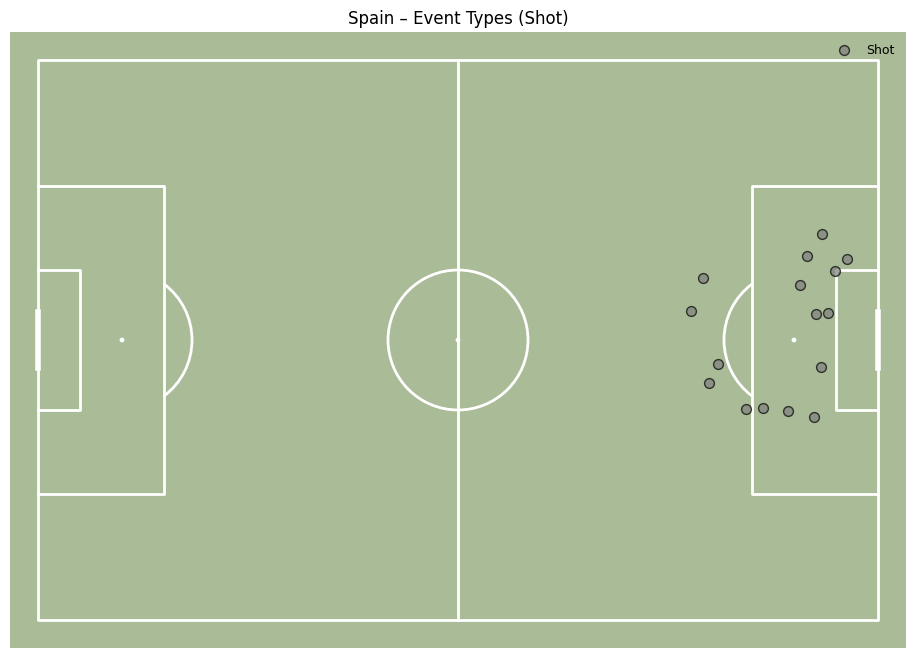

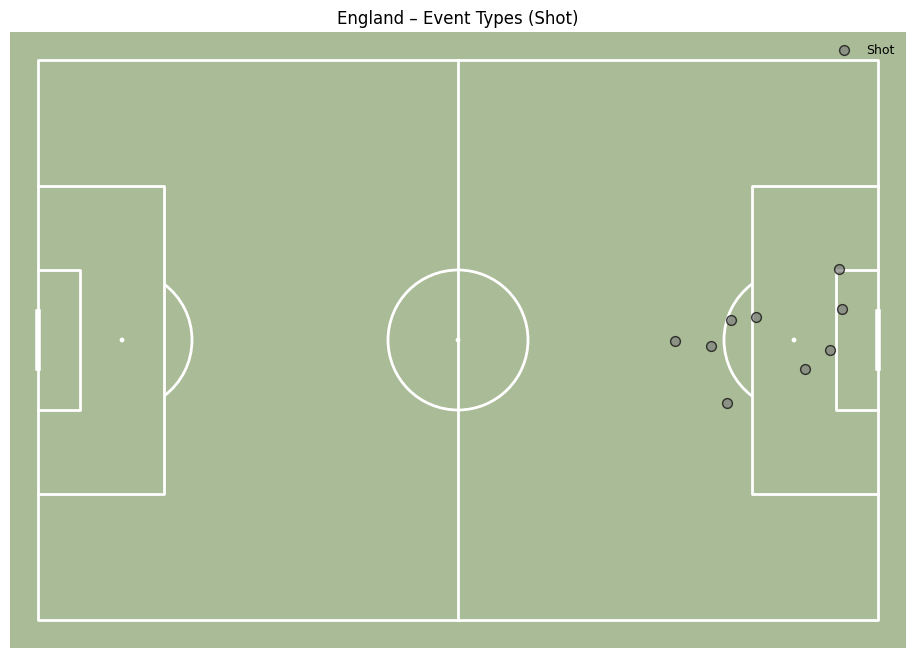

In [44]:
# 50/50, ball receipt, ball recovery, block, carry, clearance, dispossessed,
# dribble, dribbled past, duel, error, foul comitted, foul won,
# interception, miscontrol, pass, pressure, shield, shot,
# 
# goal keeper, half end, half start, injury stoppage, referee ball-drop, starting XI, substitution, tactical shift,
ShowEventTypeScatter(dfRaw, team=0, event='Shot', ax=None)
ShowEventTypeScatter(dfRaw, team=1, event='Shot', ax=None)

In [45]:
dfRaw[dfRaw['type'] == 'Tactical Shift']

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,event_uuid,visible_area,freeze_frame,player_nickname,team_name,event_name
3308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d243577a-f17f-4028-b408-77e5d51f67ae,2594,NaN,NaN,NaN,3943043,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,From Goal Kick,NaN,NaN,NaN,111,England,768,NaN,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",England,768,00:24:58.861,Tactical Shift,NaN,NaN,NaN,NaN,NaN,England,Tactical Shift
3309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53c7cfe2-9916-4a07-a7ec-51470ff54d93,3259,NaN,NaN,NaN,3943043,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,From Corner,NaN,NaN,NaN,138,England,768,NaN,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 41212, 'lineup': [{'player': {'i...",England,768,00:44:20.041,Tactical Shift,NaN,NaN,NaN,NaN,NaN,England,Tactical Shift
3310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,812eea9d-b613-45f1-91df-76bebd97d295,3260,NaN,NaN,NaN,3943043,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,From Corner,NaN,NaN,NaN,138,England,768,NaN,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Spain,772,00:44:54.242,Tactical Shift,NaN,NaN,NaN,NaN,NaN,Spain,Tactical Shift


# Formation

In [46]:
dfRaw[dfRaw['tactics'].notna()][['tactics','minute']]

,tactics,minute
0,"{'formation': 4231, 'lineup': [{'player': {'id...",0
1,"{'formation': 4231, 'lineup': [{'player': {'id...",0
3308,"{'formation': 4231, 'lineup': [{'player': {'id...",69
3309,"{'formation': 41212, 'lineup': [{'player': {'i...",89
3310,"{'formation': 4231, 'lineup': [{'player': {'id...",89


In [47]:
dfRaw.loc[dfRaw['tactics'].notna(), 'tactics']

0       {'formation': 4231, 'lineup': [{'player': {'id...
1       {'formation': 4231, 'lineup': [{'player': {'id...
3308    {'formation': 4231, 'lineup': [{'player': {'id...
3309    {'formation': 41212, 'lineup': [{'player': {'i...
3310    {'formation': 4231, 'lineup': [{'player': {'id...
Name: tactics, dtype: object

# Heatmap

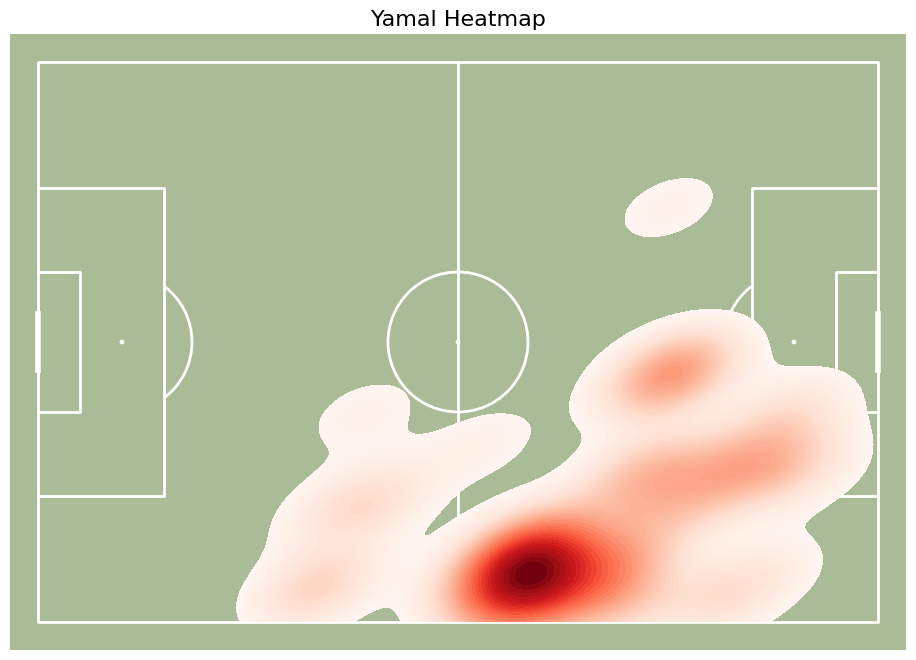

In [48]:
player = "Yamal"

mask = (
    (dfRaw['player'].str.contains(player, na=False)) &
    (dfRaw["location"].notna()) &
    (dfRaw["play_pattern"] == "Regular Play")
    )

possessionFocusedMask = (
    (dfRaw['player'].str.contains(player, na=False)) &
    (dfRaw["location"].notna()) &
    (dfRaw["type"].isin(["Pass", "Carry"]))
    )

defensiveMask = (
    (dfRaw['player'].str.contains(player, na=False)) &
    (dfRaw["location"].notna()) &
    (dfRaw["type"].isin(["Pressure", "Tackle", "Interception", "Block", "Ball Recovery"]))
    )

dfPlayer = dfRaw[mask]

dfPlayer["x"] = dfPlayer["location"].apply(lambda loc: loc[0])
dfPlayer["y"] = dfPlayer["location"].apply(lambda loc: loc[1])

pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color="#aabb97",
    line_color="white",
    linewidth=2
)

fig, ax = plt.subplots(figsize=(12, 8))
pitch.draw(ax=ax)

# KDE heatmap
pitch.kdeplot(
    dfPlayer["x"],
    dfPlayer["y"],
    ax=ax,
    fill=True,
    cmap="Reds",
    bw_adjust=0.7,
    levels=50,
    thresh=0.05
)

ax.set_title(player + " Heatmap", fontsize=16)
plt.show()

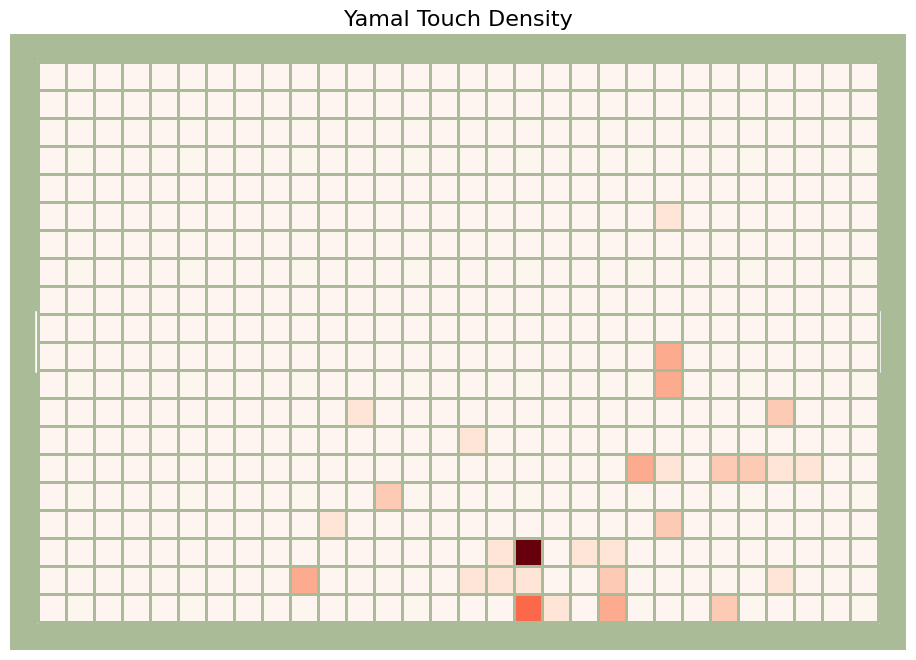

In [49]:
fig, ax = plt.subplots(figsize=(12, 8))
pitch.draw(ax=ax)

bins = (30, 20)

hm = pitch.bin_statistic(
    dfPlayer["x"],
    dfPlayer["y"],
    statistic="count",
    bins=bins,
    normalize=False
)

pitch.heatmap(
    hm,
    ax=ax,
    cmap="Reds",
    edgecolors="#aabb97"
)

ax.set_title(player + " Touch Density", fontsize=16)
plt.show()

In [50]:
def GenerateHeatmap(player: str, dfRaw: pd.DataFrame):
    # -----------------------------
    # FILTERS
    # -----------------------------
    mask_all = (
        dfRaw["player"].str.contains(player, na=False)
        & dfRaw["location"].notna()
        & (dfRaw["play_pattern"] == "Regular Play")
    )

    mask_possession = (
        dfRaw["player"].str.contains(player, na=False)
        & dfRaw["location"].notna()
        & dfRaw["type"].isin(["Pass", "Carry"])
    )

    mask_defensive = (
        dfRaw["player"].str.contains(player, na=False)
        & dfRaw["location"].notna()
        & dfRaw["type"].isin([
            "Pressure",
            "Tackle",
            "Interception",
            "Block",
            "Ball Recovery"
        ])
    )

    # -----------------------------
    # DATA
    # -----------------------------
    df_all = dfRaw[mask_all].copy()
    df_possession = dfRaw[mask_possession].copy()
    df_defensive = dfRaw[mask_defensive].copy()

    for df in (df_all, df_possession, df_defensive):
        df["x"] = df["location"].apply(lambda l: l[0])
        df["y"] = df["location"].apply(lambda l: l[1])

    # -----------------------------
    # PITCH
    # -----------------------------
    pitch = Pitch(
        pitch_type="statsbomb",
        pitch_color="#aabb97",
        line_color="white",
        linewidth=2
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # -----------------------------
    # PLOTS
    # -----------------------------
    for ax, data, title in zip(
        axes,
        [df_all, df_possession, df_defensive],
        ["All Actions", "Passes & Carries", "Defensive Actions"]
    ):
        pitch.draw(ax=ax)

        pitch.kdeplot(
            data["x"],
            data["y"],
            ax=ax,
            fill=True,
            cmap="Reds",
            bw_adjust=0.7,
            levels=50,
            thresh=0.05,
            alpha=0.7
        )

        ax.set_title(f"{player} – {title}", fontsize=12)

    fig.suptitle(f"{player} Heatmaps in Open Play", fontsize=16, y=0.82)
    plt.show()

    return fig, axes


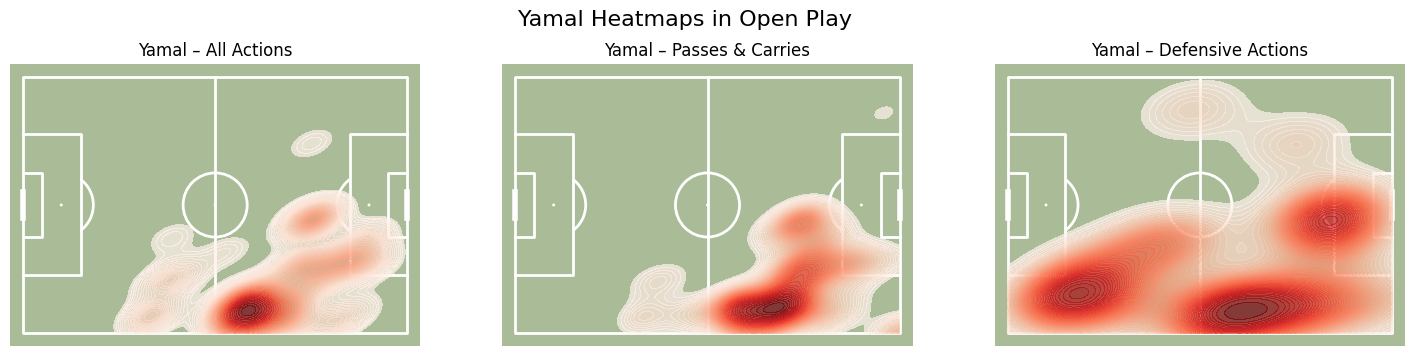

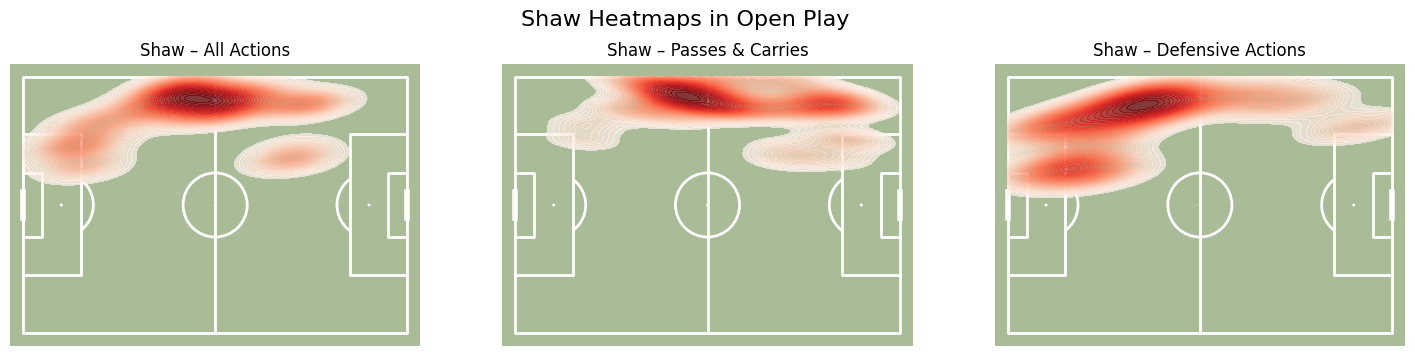

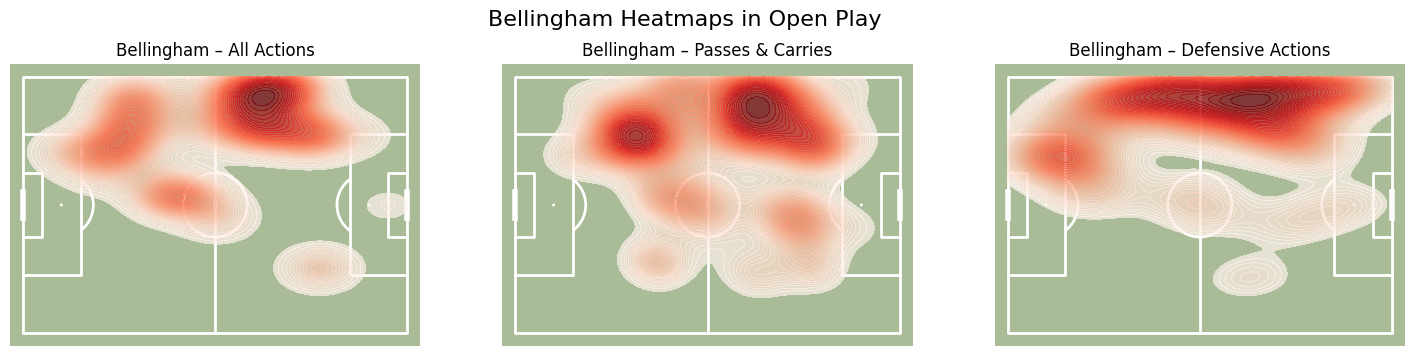

In [51]:
fig, axes = GenerateHeatmap("Yamal", dfRaw)
fig, axes = GenerateHeatmap("Shaw", dfRaw)
fig, axes = GenerateHeatmap("Bellingham", dfRaw)

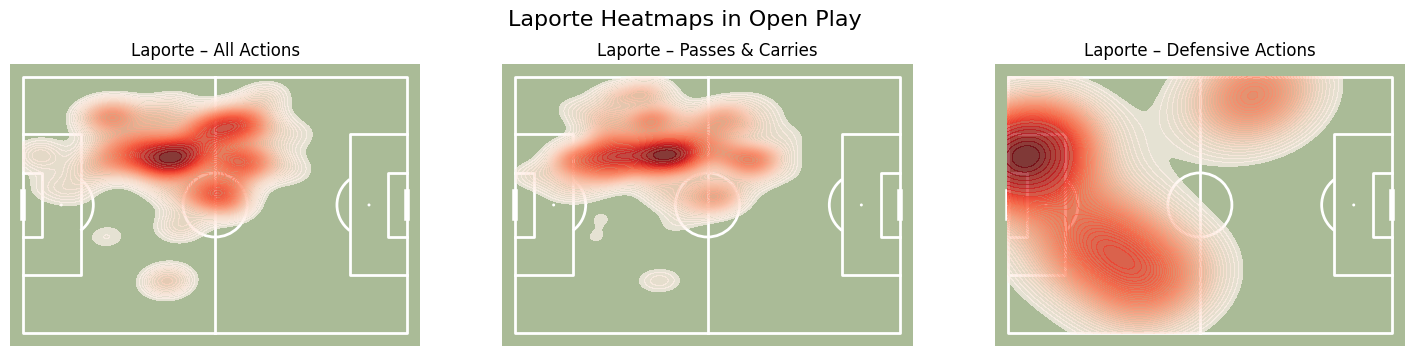

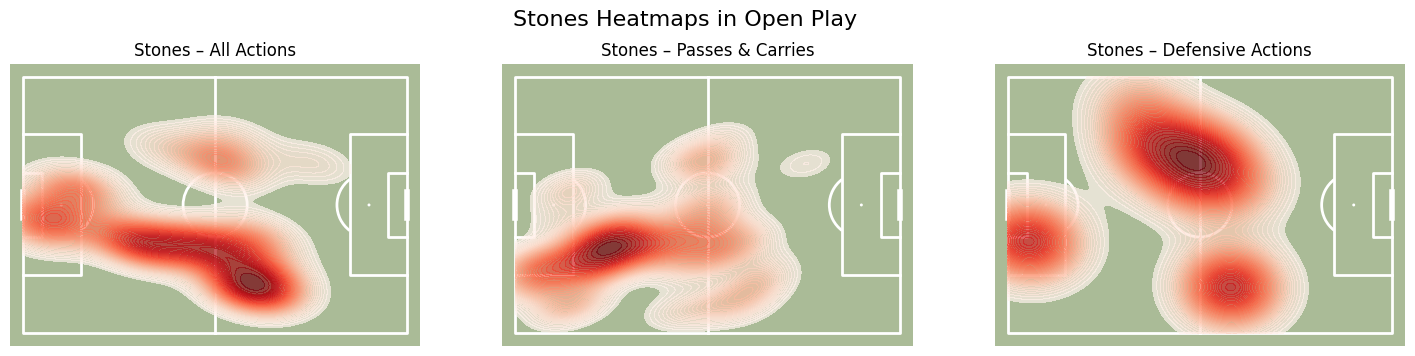

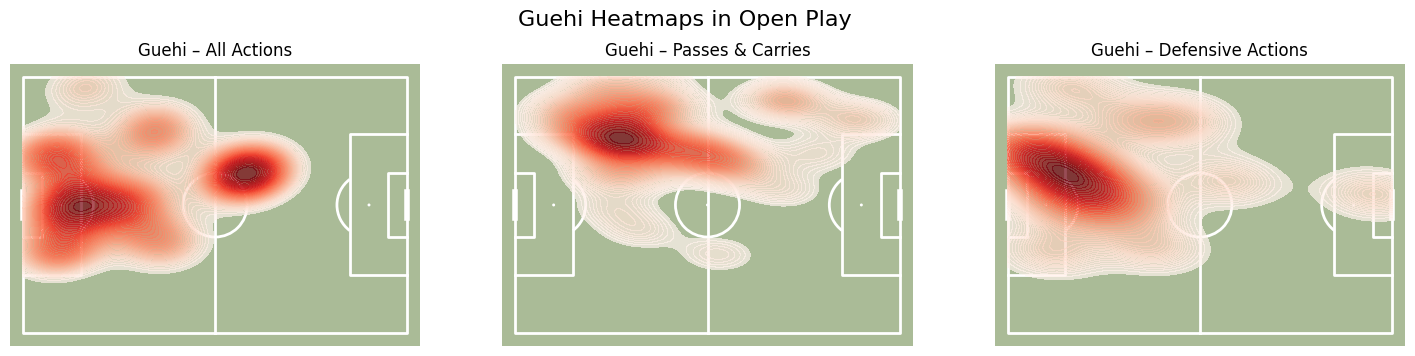

In [52]:
fig, axes = GenerateHeatmap("Laporte", dfRaw)
fig, axes = GenerateHeatmap("Stones", dfRaw)
fig, axes = GenerateHeatmap("Guehi", dfRaw)

# Rodri

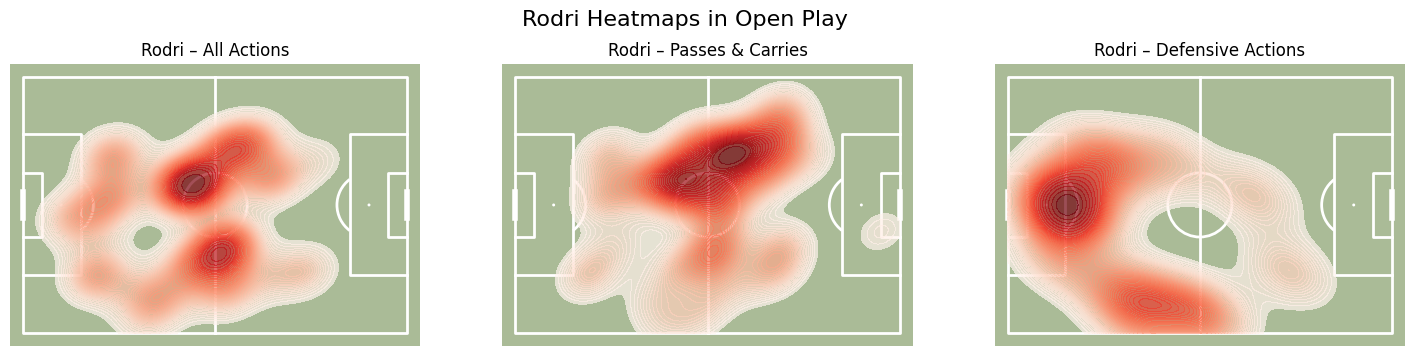

In [53]:
fig, axes = GenerateHeatmap("Rodri", dfRaw)

In [54]:
dfRodriPassSuccess = dfRodriPass[dfRodri['pass_outcome'].isna()]
dfRodriPassFailed = dfRodriPass[dfRodri['pass_outcome'].notna()]

successRate = len(dfRodriPassSuccess) / len(dfRodriPass) * 100;
successRate = len(dfRodriPassFailed) / len(dfRodriPass) * 100;

print(f'Successful passes: {successRate:.2f} %')
print(len(dfRodriPassFailed) / len(dfRodriPass))

Successful passes: 9.38 %
0.09375


In [55]:
mask = (
    (dfRaw['player'].str.contains('Rodrigo', na=False)) &
    (dfRaw['type'] == 'Pass')
)
passColumns = [col for col in dfRaw.columns if 'pass' in col]

dfRodriPass = dfRaw[mask]
dfRodriPass[passColumns]

,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,shot_key_pass_id
16,NaN,-2.493536,NaN,Left Foot,NaN,NaN,"[26.1, 60.7]",NaN,Ground Pass,NaN,26.340273,NaN,NaN,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,NaN,NaN,NaN
48,NaN,1.506072,NaN,Right Foot,NaN,NaN,"[50.4, 55.6]",NaN,Ground Pass,NaN,21.645323,NaN,NaN,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,NaN,NaN,NaN
68,NaN,1.892547,NaN,Right Foot,NaN,NaN,"[55.3, 47.1]",NaN,Ground Pass,NaN,25.614449,NaN,NaN,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,NaN,NaN,NaN
84,NaN,1.570796,NaN,Left Foot,NaN,NaN,"[63.4, 64.0]",NaN,Ground Pass,NaN,10.600000,NaN,NaN,NaN,Robin Aime Robert Le Normand,22128.0,NaN,NaN,NaN,NaN,NaN,NaN
87,NaN,-1.808171,NaN,Right Foot,NaN,NaN,"[57.0, 35.3]",NaN,Ground Pass,NaN,25.515486,NaN,NaN,NaN,Aymeric Laporte,4353.0,NaN,NaN,NaN,NaN,NaN,NaN
106,NaN,-0.288975,NaN,Right Foot,NaN,NaN,"[99.2, 23.9]",NaN,Ground Pass,NaN,7.720104,NaN,NaN,NaN,Nicholas Williams Arthuer,68574.0,NaN,NaN,NaN,NaN,Recovery,NaN
114,NaN,-1.164307,NaN,Head,NaN,NaN,"[76.3, 6.5]",NaN,High Pass,NaN,16.439587,NaN,NaN,NaN,Fabián Ruiz Peña,6655.0,NaN,NaN,NaN,NaN,NaN,NaN
153,True,-1.677824,c825856a-5a21-4507-b9e2-ea07b5bf4cca,NaN,NaN,NaN,"[112.9, 36.2]",NaN,High Pass,NaN,12.169634,NaN,NaN,NaN,Robin Aime Robert Le Normand,22128.0,True,NaN,NaN,NaN,NaN,NaN
161,NaN,-1.654711,NaN,Right Foot,NaN,NaN,"[47.5, 27.1]",NaN,Ground Pass,NaN,32.213352,NaN,NaN,NaN,Aymeric Laporte,4353.0,NaN,NaN,NaN,NaN,NaN,NaN
190,NaN,-0.178879,NaN,Right Foot,NaN,NaN,"[58.8, 47.7]",NaN,High Pass,NaN,27.539427,NaN,Incomplete,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
def PlotPass(row, df):
    # 1. IMPORTANT: Clear the current figure to prevent stacking/not refreshing
    plt.close('all') 
    
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#aabb97', line_color='white', linewidth=2)
    fig, ax = pitch.draw(figsize=(12, 8))
    
    # Get the data
    df[['xStart','yStart']] = pd.DataFrame(df.location.tolist(), index=df.index)
    df[['xEnd','yEnd']] = pd.DataFrame(df.pass_end_location.tolist(), index=df.index)
    
    dfPlot = df.iloc[row]

    # Calculate totals from freeze_frame
    freeze_frame = dfPlot.get('freeze_frame', [])
    teammatesCount = len([p for p in freeze_frame if p['teammate']])
    opponentsCount = len([p for p in freeze_frame if not p['teammate']])

    # Draw your pass
    pitch.scatter(x=dfPlot['xStart'], y=dfPlot['yStart'], ax=ax, c='blue', s=100, zorder=3)
    pitch.lines(xstart=dfPlot['xStart'], ystart=dfPlot['yStart'], 
                xend=dfPlot['xEnd'], yend=dfPlot['yEnd'], 
                ax=ax, comet=True, color='white', lw=3)

    # Draw freeze frame
    if 'freeze_frame' in dfPlot and isinstance(dfPlot['freeze_frame'], list):
        for player in dfPlot['freeze_frame']:
            color = 'green' if player['keeper'] else 'blue' if player['teammate'] else 'red'
            pitch.scatter(x=player['location'][0], y=player['location'][1], 
                          ax=ax, c=color, s=80, edgecolors='white')
    
    # Update Title with the info
    playerName = dfPlot['player']
    minute = dfPlot.get('minute', 'N/A')
    under_pressure = "Yes" if dfPlot.get('under_pressure') == 1 else "No"
    pass_outcome = "Complete" if pd.isna(dfPlot.get('pass_outcome')) else dfPlot['pass_outcome']
    
    ax.set_title(f"{playerName} {row} | {pass_outcome} pass to {dfPlot['pass_recipient']}, {dfPlot['pass_body_part']}\nUnder Pressure: {under_pressure} | Minute: {minute}", fontsize=16, pad=10)
    
    # Add Legend with dynamic counts
    # We create empty scatter points just to generate the legend labels
    ax.scatter([], [], c='blue', label=f'Teammates: {teammatesCount}')
    ax.scatter([], [], c='red', label=f'Opponents: {opponentsCount}')
    ax.legend(loc='upper right', fontsize=9, frameon=True)
    
    # 4. Force display
    plt.show()
    
# Create the interactive slider
dfPass = dfRodriPass[dfRodriPass['pass_height'] == 'High Pass']
interact(PlotPass, row=(0, len(dfPass)-1), df=fixed(dfPass))


interactive(children=(IntSlider(value=2, description='row', max=5), Output()), _dom_classes=('widget-interact'…

<function __main__.PlotPass(row, df)>

In [57]:
dfSpainAllEvents = pd.concat(
    [sb.events(match_id=mid) for mid in dfSpainAll['match_id']],
    ignore_index=True
)

rodriFilter = (dfSpainAllEvents['player'].str.contains('Rodrigo')) \
    & (dfSpainAllEvents['type'] == 'Pass') \
    & (dfSpainAllEvents['pass_switch'].notna())

dfSpainAllEvents[rodriFilter].head(5)


,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,clearance_other,foul_committed_type,miscontrol_aerial_won,bad_behaviour_card,ball_recovery_offensive,dribble_no_touch,pass_deflected,goalkeeper_shot_saved_off_target,shot_saved_off_target,foul_committed_penalty,foul_won_penalty,shot_redirect
393,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.775714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bdd474b9-69f1-4fa5-81b7-7a068f8bab1d,1369,NaN,NaN,"[77.5, 31.6]",3943043,37,NaN,NaN,NaN,1.134169,NaN,Right Foot,NaN,NaN,"[98.5, 76.6]",NaN,High Pass,NaN,49.658836,NaN,NaN,NaN,Nicholas Williams Arthuer,68574.0,NaN,True,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,60,Spain,772,[0813d349-cd7f-4892-acdf-be271605dcfe],11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spain,772,00:37:11.924,Pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3672,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.286018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36676866-4090-4794-86fb-1b5a1e5e20e2,1219,NaN,NaN,"[32.9, 56.6]",3942752,35,NaN,NaN,NaN,-1.466300,NaN,Right Foot,NaN,NaN,"[37.2, 15.6]",NaN,Ground Pass,NaN,41.224873,NaN,NaN,NaN,Aymeric Laporte,4353.0,NaN,True,NaN,NaN,NaN,1,From Free Kick,Rodrigo Hernández Cascante,6765.0,Right Defensive Midfield,52,Spain,772,[9e069b49-b6f4-43ae-85e0-6cd00c3324ef],12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spain,772,00:35:12.329,Pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.222108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4ed221c4-bd83-4cc3-a9b7-7695c2aa45ed,1647,NaN,NaN,"[89.3, 60.6]",3942226,45,NaN,NaN,NaN,-1.368422,NaN,Right Foot,NaN,NaN,"[98.8, 14.3]",NaN,High Pass,NaN,47.264576,NaN,NaN,NaN,Marc Cucurella Saseta,17620.0,NaN,True,NaN,NaN,NaN,1,Regular Play,Rodrigo Hernández Cascante,6765.0,Center Defensive Midfield,71,Spain,772,[6623a1be-243d-43c5-a341-485572ff58dc],43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spain,772,00:45:43.144,Pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11283,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.737944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,524c9e75-e1d1-41c6-bf3f-c664beb2ac17,577,NaN,NaN,"[84.7, 48.5]",3941018,11,NaN,NaN,NaN,-1.239833,NaN,Right Foot,NaN,NaN,"[99.2, 6.3]",NaN,High Pass,NaN,44.621630,NaN,NaN,NaN,Marc Cucurella Saseta,17620.0,NaN,True,NaN,NaN,NaN,1,From Corner,Rodrigo Hernández Cascante,6765.0,Center Defensive Midfield,18,Spain,772,[f07e586d

In [58]:
dfRodriAllPassSwitch = dfSpainAllEvents[rodriFilter].groupby('match_id').size()\
    .reindex(dfSpainAll['match_id'], fill_value=0)\
    .reset_index(name='count')

dfRodriAllPassSwitch

,match_id,count
0,3943043,1
1,3942752,1
2,3942226,1
3,3941018,4
4,3930179,0
5,3930172,4
6,3930160,2


In [59]:
dfRodriAllPassSwitch.merge(dfSpainAll, on='match_id')

,match_id,count,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_id,competition_country_name,competition_name,competition,season_id,season,home_team_id,home_team,home_team_gender,home_team_group,home_team_country_id,home_team_country_name,away_team_id,away_team,away_team_gender,away_team_group,away_team_country_id,away_team_country_name,competition_stage_id,competition_stage,stadium_id,stadium,stadium_country_id,stadium_country_name,referee_id,referee,referee_country_id,referee_country_name,home_managers,away_managers,home_manager_id,home_manager_name,home_manager_nickname,home_manager_dob,home_manager_country_id,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
0,3943043,1,2024-07-14,22:00:00.000,2,1,available,available,2024-07-15T15:48:50.315500,2024-07-15T15:52:24.778809,7,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,768,England,male,None,68,England,26,Final,367,Olympiastadion Berlin,85,Germany,79,François Letexier,78,France,Luis de la Fuente Castillo,Gareth Southgate,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,277,Gareth Southgate,NaN,1970-09-03,68,England,1.1.0,2,2
1,3942752,1,2024-07-09,22:00:00.000,2,1,available,available,2024-07-10T08:51:07.032303,2024-07-10T13:01:26.597509,6,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,771,France,male,None,78,France,15,Semi-finals,4867,Allianz Arena,85,Germany,943,Slavko Vinčić,208,Slovenia,Luis de la Fuente Castillo,Didier Deschamps,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,545,Didier Deschamps,NaN,1968-10-15,78,France,1.1.0,2,2
2,3942226,1,2024-07-05,19:00:00.000,2,1,available,available,2024-07-13T03:52:05.176875,2024-07-13T03:52:43.383929,5,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,770,Germany,male,None,85,Germany,11,Quarter-finals,369,MHPArena,85,Germany,8,Anthony Taylor,68,England,Luis de la Fuente Castillo,Julian Nagelsmann,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,445,Julian Nagelsmann,NaN,1987-07-23,85,Germany,1.1.0,2,2
3,3941018,4,2024-06-30,22:00:00.000,4,1,available,available,2024-07-12T06:06:58.963038,2024-07-12T06:08:12.572176,4,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,2138,Georgia,male,None,84,Georgia,33,Round of 16,363,RheinEnergieStadion,85,Germany,79,François Letexier,78,France,Luis de la Fuente Castillo,Willy Sagnol,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,752,Willy Sagnol,NaN,1977-03-18,78,France,1.1.0,2,2
4,3930179,0,2024-06-24,22:00:00.000,0,1,available,available,2024-07-01T06:01:14.238710,2024-07-01T06:07:22.418137,3,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,906,Albania,male,None,3,Albania,772,Spain,male,None,214,Spain,10,Group Stage,4866,Merkur Spiel-Arena,85,Germany,1062,Glenn Nyberg,220,Sweden,Sylvio Mendes Campos Junior,Luis de la Fuente Castillo,1877,Sylvio Mendes Campos Junior,Sylvinho,1974-04-12,31,Brazil,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,1.1.0,2,2
5,3930172,4,2024-06-20,22:00:00.000,1,0,available,available,2024-07-12T00:15:20.599402,2024-07-12T00:16:51.275112,2,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,914,Italy,male,None,112,Italy,10,Group Stage,370,VELTINS-Arena,85,Germany,943,Slavko Vinčić,208,Slovenia,Luis de la Fuente Castillo,Luciano Spalletti,5588,Luis de la Fuente Castillo,Luis de la Fuente,1961-06-21,214,Spain,399,Luciano Spalletti,NaN,1959-03-07,112,Italy,1.1.0,2,2
6,3930160,2,2024-06-15,19:00:00.000,3,0,available,available,2024-07-12T03:36:29.899268,2024-07-12T03:40:20.513429,1,55,Europe,UEFA Euro,Europe - UEFA Euro,282,2024,772,Spain,male,None,214,Spain,785,Croatia,male,None,56,Croatia,10,Gr

# PPDA

In [60]:
# "Ball Recovery" is outcome, not pressure / "Block" is shot-based, often too late
# "Clearance" is defensive desperation, not pressing
# !!!!! Take only ["Pressure", "Tackle", "Interception"] !!!!!
PPDA_X_MIN = 0
PPDA_X_MAX = 80

def AddCoordinates(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["x"] = df["location"].apply(
        lambda l: l[0] if isinstance(l, (list, tuple)) and len(l) >= 2 else np.nan
    )
    df["y"] = df["location"].apply(
        lambda l: l[1] if isinstance(l, (list, tuple)) and len(l) >= 2 else np.nan
    )

    return df


def GetOpponentPassesDF(df: pd.DataFrame, defending_team: str, x_min: int =PPDA_X_MIN, x_max: int =PPDA_X_MAX):
    return df[
        (df["team"] != defending_team) &
        (df["type"] == "Pass") &
        (df["pass_outcome"].isna()) &      # completed passes
        (df["x"].notna()) &
        (df["x"] <= x_max) &
        (df["x"] >= x_min)
    ]

def GetDefensiveActionsDF(df: pd.DataFrame, defending_team: str, x_min: int =PPDA_X_MIN, x_max: int =PPDA_X_MAX):
    return df[
        (df["team"] == defending_team) &
        (df["type"].isin(["Pressure", "Tackle", "Interception"])) &
        (df["x"].notna()) &
        (df["x"] <= x_max) &
        (df["x"] >= x_min)
    ]

def CalculatePPDA(df, defending_team, x_min=PPDA_X_MIN, x_max=PPDA_X_MAX):
    dfWithCoordinates = AddCoordinates(df)

    opponentPasses = GetOpponentPassesDF(dfWithCoordinates, defending_team, x_min, x_max)
    defensiveActions = GetDefensiveActionsDF(dfWithCoordinates, defending_team, x_min, x_max)

    if len(defensiveActions) == 0:
        return float("inf")

    return len(opponentPasses) / len(defensiveActions)



print(f"PPDA of Spain: {CalculatePPDA(dfRaw, defending_team="Spain"):.2f}")
print(f"PPDA of England: {CalculatePPDA(dfRaw, defending_team="England"):.2f}")


PPDA of Spain: 1.91
PPDA of England: 2.97


# Tactical changes

In [61]:
dfRaw.columns
dfRaw[(dfRaw['substitution_replacement'].notna())][['player', 'substitution_replacement', 'minute']]

,player,substitution_replacement,minute
3299,Rodrigo Hernández Cascante,Martín Zubimendi Ibáñez,45
3300,Harry Kane,Ollie Watkins,60
3301,Álvaro Borja Morata Martín,Mikel Oyarzabal Ugarte,67
3302,Kobbie Mainoo,Cole Palmer,69
3303,Robin Aime Robert Le Normand,José Ignacio Fernández Iglesias,82
3304,Lamine Yamal Nasraoui Ebana,Mikel Merino Zazón,88
3305,Phil Foden,Ivan Toney,89


In [62]:
dfRaw[(dfRaw['tactics'].notna())][['tactics', 'minute']]

,tactics,minute
0,"{'formation': 4231, 'lineup': [{'player': {'id...",0
1,"{'formation': 4231, 'lineup': [{'player': {'id...",0
3308,"{'formation': 4231, 'lineup': [{'player': {'id...",69
3309,"{'formation': 41212, 'lineup': [{'player': {'i...",89
3310,"{'formation': 4231, 'lineup': [{'player': {'id...",89


# Defensive actions

In [63]:
dfRaw[dfRaw["type"].isin(["Pressure", "Tackle", "Interception", "Ball Recovory", "Block", "Clearance"])].groupby('player').count()

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_won_advantage,foul_won_defensive,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,injury_stoppage_in_chain,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,event_uuid,visible_area,freeze_frame,player_nickname,team_name,event_name
player,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Aymeric Laporte,0,0,0,0,0,0,0,2,7,4,2,1,0,0,0,0,0,0,11,0,0,0,0,0,0,0,0,0,0,0,11,11,0,0,11,11,11,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11,11,11,11,11,11,11,11,11,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11,11,11,11,7,11,11,11,11,11,11
Bukayo Saka,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0,20,20,0,0,20,20,20,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,20,20,20,20,20,20,20,17,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,20,20,20,20,1,14,14,14,20,20,20
Cole Palmer,0,0,0,0,0,0,0,0,1,0,1,0,2,0,0,0,0,0,8,0,0,0,0,0,0,0,0,0,0,0,8,8,0,0,8,8,8,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,8,8,8,8,8,8,8,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,8,8,8,1,3,3,3,8,8,8
Daniel Carvajal Ramos,0,0,0,0,0,0,0,1,2,1,0,1,5,0,0,0,0,0,20,0,0,0,0,0,0,0,0,0,0,0,20,20,0,0,20,20,20,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,20,20,20,20,20,20,20,19,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,20,20,20,20,2,15,15,15,20,20,20
Daniel Olmo Carvajal,0,0,0,0,0,1,0,0,0,0,0,0,8,0,0,0,0,0,29,0,0,0,0,0,0,0,0,0,0,0,29,29,0,1,29,29,29,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,29,29,29,29,29,29,29,27,29,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,29,29,29,29,0,25,25,25,29,29,29
Declan Rice,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,17,0,0,0,0,0,0,0,0,0,0,0,17,17,0,1,17,17,17,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,17,17,17,17,17,17,17,16,17,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,17,17,17,17,0,14,14,14,17,17,17
Fabián Ruiz Peña,0,0,0,0,0,0,0,0,0,0,0,0,7,0,0,0,0,0,21,0,0,0,0,0,0,0,0,0,0,0,21,21,0,0,21,21,21,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,21,21,21,21,21,21,21,19,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,21,21,21,21,0,16,16,16,21,21,21
Harry Kane,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,0,0,0,0,0,0,0,0,0,0,0,8,8,0,0,8,8,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,8,8,8,8,8,8,7,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,8,8,8,0,6,6,6,8,8,8
John Stones,0,0,0,0,0,0,0,2,8,5,2,1,2,0,0,0,0,0,19,0,0,0,0,0,0,0,0,0,0,0,19,19,0,0,19,19,19,0,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,19,19,19,19,19,19,19,16,19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,19,19,19,19,8,16,16,16,19,19,19


In [64]:
dfRaw[dfRaw['counterpress'].notna()].groupby('player')[['counterpress']].count().sort_values(by='counterpress', ascending=False)

,counterpress
player,
Fabián Ruiz Peña,10
Daniel Olmo Carvajal,9
Daniel Carvajal Ramos,8
Phil Foden,8
Martín Zubimendi Ibáñez,7
Jude Bellingham,7
Kobbie Mainoo,6
Kyle Walker,5
Álvaro Borja Morata Martín,5


In [65]:
#dfRaw[dfRaw['type'].isin(['Carry'])].filter(like='dribble')
#dfRaw.filter(like='dribble')
#dfRaw[dfRaw['type'].isin(['Carry'])].filter(like='dribble').groupby('player').count()
dfRaw[dfRaw['dribble_outcome'].notna()].groupby('player').count().filter(like='dribble')

,dribble_nutmeg,dribble_outcome,dribble_overrun
player,,,
Bukayo Saka,0,1,0
Cole Palmer,0,1,0
Daniel Carvajal Ramos,0,2,0
Daniel Olmo Carvajal,0,1,0
Declan Rice,0,2,0
Fabián Ruiz Peña,0,1,0
Jude Bellingham,1,1,0
Kobbie Mainoo,0,3,1
Kyle Walker,0,2,0


# Passes

In [66]:
dfRaw[dfRaw['pass_length'].notna()]['pass_length'].describe()

count    917.000000
mean      21.088548
std       14.628333
min        1.264911
25%       11.543396
50%       17.241810
75%       26.122787
max      103.551540
Name: pass_length, dtype: float64

In [67]:
# More than 2 sigma
dfLongPasses = dfRaw[(dfRaw['pass_length'] > 35)]

dfLongPasses['player'].value_counts()

player
Jordan Pickford                 25
Kyle Walker                     10
John Stones                     10
Daniel Carvajal Ramos            9
Unai Simón Mendibil              9
Nicholas Williams Arthuer        8
Aymeric Laporte                  6
Fabián Ruiz Peña                 6
Robin Aime Robert Le Normand     5
Lamine Yamal Nasraoui Ebana      4
Daniel Olmo Carvajal             3
Luke Shaw                        3
Declan Rice                      3
Marc Guehi                       3
Harry Kane                       2
Martín Zubimendi Ibáñez          2
Cole Palmer                      2
Phil Foden                       1
Jude Bellingham                  1
Marc Cucurella Saseta            1
Álvaro Borja Morata Martín       1
Rodrigo Hernández Cascante       1
Kobbie Mainoo                    1
Mikel Oyarzabal Ugarte           1
Name: count, dtype: int64

In [68]:
dfLongPasses = dfRaw[(dfRaw['pass_length'] > 35) & (dfRaw['freeze_frame'].notna())] 
dfLongPassesStones = dfLongPasses[(dfLongPasses['player'].str.contains('Stones'))]

interact(PlotPass, row=(0, len(dfLongPassesStones)-1), df=fixed(dfLongPassesStones))

interactive(children=(IntSlider(value=3, description='row', max=6), Output()), _dom_classes=('widget-interact'…

<function __main__.PlotPass(row, df)>

In [ ]:
dfLongPasses = dfRaw[(dfRaw['pass_length'] > 35) & (dfRaw['freeze_frame'].notna())] 

# 1. Calculate the boolean range
dfLongPasses['pass_forward'] = dfLongPasses['pass_angle'].between(-np.pi/3, np.pi/3).astype('boolean')

# 2. Re-insert NaNs where the original angle was missing
dfLongPasses.loc[dfLongPasses['pass_angle'].isna(), 'pass_forward'] = np.nan

dfLongPassesLeNormand = dfLongPasses[(dfLongPasses['pass_forward'] == True) & (dfLongPasses['player'].str.contains('Walker'))]
interact(PlotPass, row=(0, len(dfLongPassesLeNormand)-1), df=fixed(dfLongPassesLeNormand))

interactive(children=(IntSlider(value=1, description='row', max=2), Output()), _dom_classes=('widget-interact'…

<function __main__.PlotPass(row, df)>

In [ ]:
dfLongPasses = dfRaw[(dfRaw['pass_length'] > 35) & (dfRaw['freeze_frame'].notna())] 

# 1. Calculate the boolean range
dfLongPasses['pass_forward'] = dfLongPasses['pass_angle'].between(-np.pi/3, np.pi/3).astype('boolean')

# 2. Re-insert NaNs where the original angle was missing
dfLongPasses.loc[dfLongPasses['pass_angle'].isna(), 'pass_forward'] = np.nan

dfLongPassesLeNormand = dfLongPasses[(dfLongPasses['pass_forward'] == True) & (dfLongPasses['player'].str.contains('Normand'))]
interact(PlotPass, row=(0, len(dfLongPassesLeNormand)-1), df=fixed(dfLongPassesLeNormand))

interactive(children=(IntSlider(value=1, description='row', max=3), Output()), _dom_classes=('widget-interact'…

<function __main__.PlotPass(row, df)>